![](https://logoeps.com/wp-content/uploads/2013/04/pontificia-universidad-javeriana-vector-logo.png)
# PONTIFICIA UNIVERSIDAD JAVERIANA

### Procesamiento de Datos

**Fecha:** 2 de Octubre de 2026

**Estudiantes:**
- Daniel Santiago Avila Medina
- Javier Felipe Aldana Jaramillo
- Ivan Alejandro Pardo Montenegro

**Tema:** PySpark para el diagnóstico territorial de arrestos y siniestros viales en la ciudad de Nueva York

**Entrega:** Primera. Entendimiento del negocio y entendimiento de los datos

**Objetivos:**
- Aplicar la metodología CRISP-DM sobre datos abiertos de la ciudad de Nueva York, en las fases de entendimiento del negocio y de los datos
- Documentar de forma exhaustiva cada decisión de procesamiento y su justificación, de modo que cada cifra del documento escrito sea trazable hasta el código que la produce
- Construir indicadores territoriales normalizados por población, que permitan comparar distritos de tamaños muy distintos sin inducir conclusiones erróneas
- Evaluar la calidad de los datos, distinguiendo los valores faltantes de los no aplicables y de los encubiertos bajo un marcador, y proponer técnicas de tratamiento
- Crear y analizar gráficas que documenten de forma académica el comportamiento territorial y temporal de los indicadores
- Plantear las preguntas de negocio que se responderán en la entrega final

**Clúster:** Apache Spark 4.2.0 en modo standalone, 6 nodos, 24 núcleos y 86 GB de RAM

---

> **Requisito de ejecución:** seleccionar el kernel `PySpark 4.2 (Python 3.11)`. Dicho kernel define `PYSPARK_PYTHON=/opt/cluster/python311/bin/python3`, necesario porque PySpark 4.2 requiere Python 3.10 o superior mientras que el intérprete del sistema es 3.9.


## 1. Inicialización de la sesión de Spark


In [1]:
import time, re
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import (StructType, StructField, StringType,
                               IntegerType, DoubleType)
import pandas as pd

pd.set_option('display.max_rows', 120)
pd.set_option('display.width', 200)

spark = (SparkSession.builder
         .appName('NY_Entrega1_Aldana_Avila_Pardo')
         .config('spark.sql.session.timeZone', 'America/New_York')
         .getOrCreate())

spark.sparkContext.setLogLevel('ERROR')

print('Version de Spark :', spark.version)
print('Maestro          :', spark.sparkContext.master)
print('Aplicacion       :', spark.sparkContext.applicationId)


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


/opt/cluster/spark/python/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


26/10/02 19:48:49 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/10/02 19:48:49 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


Version de Spark : 4.2.0
Maestro          : spark://10.43.97.58:7077
Aplicacion       : app-20261002194850-0010


Se consulta la interfaz de administración del nodo maestro para documentar la capacidad
total del clúster. Conviene advertir que el número de *ejecutores* activos no coincide con
el de *nodos trabajadores*: al estar habilitada la asignación dinámica
(`spark.dynamicAllocation.enabled`), Spark no solicita ejecutores mientras no exista trabajo
pendiente. Por ese motivo la ocupación real se mide más adelante, una vez ejecutado el
procesamiento.


In [2]:
import json
from urllib.request import urlopen

def capacidad_cluster(url='http://10.43.97.58:8081/json/'):
    with urlopen(url, timeout=15) as r:
        j = json.loads(r.read().decode())
    vivos = [w for w in j.get('workers', []) if w.get('state') == 'ALIVE']
    return pd.DataFrame([{'Nodo': w['host'],
                          'Nucleos': w['cores'],
                          'Memoria (MB)': w['memory'],
                          'Estado': w['state']} for w in vivos]), j

cap, crudo = capacidad_cluster()
print('Estado del maestro :', crudo['status'])
print('Nucleos totales    :', crudo['cores'])
print('Memoria total (MB) :', crudo['memory'])
cap


Estado del maestro : ALIVE
Nucleos totales    : 32
Memoria total (MB) : 117408


,Nodo,Nucleos,Memoria (MB),Estado
0,10.43.97.67,4,14676,ALIVE
1,10.43.97.61,4,14676,ALIVE
2,10.43.97.71,4,14676,ALIVE
3,10.43.97.63,4,14676,ALIVE
4,10.43.97.59,4,14676,ALIVE
5,10.43.97.58,4,14676,ALIVE
6,10.43.97.71,4,14676,ALIVE
7,10.43.97.67,4,14676,ALIVE


In [3]:
def ejecutores_activos():
    """Ejecutores asignados a la aplicacion en este instante.

    La interfaz Java SparkExecutorInfo de Spark 4.2 expone host() y port(),
    pero no executorId(); la identidad del ejecutor se deriva de host:puerto.
    La primera entrada corresponde al proceso conductor (driver).
    """
    def corto(h):
        # Los nodos se reportan indistintamente por nombre de dominio o por IP
        return h if re.match(r'^\d+\.\d+\.\d+\.\d+$', h) else h.split('.')[0]
    infos = spark.sparkContext._jsc.sc().statusTracker().getExecutorInfos()
    return len(infos), sorted({corto(e.host()) for e in infos})

n, nodos = ejecutores_activos()
print('Entradas de ejecutor antes de procesar:', n)
print('Nodos                                 :', nodos)


Entradas de ejecutor antes de procesar: 1
Nodos                                 : ['NBDG41']


## 2. Colección de datos

Los siete conjuntos residen en el directorio `/opt/cluster/data/grupo1`, exportado por NFS
desde el nodo maestro y montado en la misma ruta por los seis nodos, de modo que todos los
ejecutores acceden a los archivos mediante una ruta idéntica.

Se declaran **esquemas explícitos** en lugar de recurrir a `inferSchema`. Esto evita una
pasada adicional de lectura sobre archivos de gran tamaño y, sobre todo, impide que Spark
infiera tipos incorrectos en columnas como los puntajes SAT, que contienen el marcador `s`
para los valores suprimidos por confidencialidad.


### Convención de versionado de los DataFrames

Cada etapa de transformación se materializa en un DataFrame distinto, numerado de forma progresiva, en lugar de reasignar una misma variable. Esto permite inspeccionar el estado de los datos antes y después de cada operación, que es precisamente lo que exige documentar el tratamiento.

Dado que el proyecto emplea diez conjuntos de datos, un contador único resultaría ilegible. Se antepone por ello el nombre del conjunto al número de versión:

| Versión | Significado |
|---|---|
| `dfXxx00` | Lectura en crudo, tal como viene del archivo |
| `dfXxx01` | Primera transformación: renombrado o selección de atributos |
| `dfXxx02` | Segunda transformación: conversión de tipos |
| `dfXxx03` y siguientes | Uniones, derivaciones y enriquecimientos |

Así, `dfCrashes00` es el conjunto de siniestros recién leído y `dfCrashes02` el mismo conjunto con los nombres normalizados y la fecha convertida a tipo `date`.


In [4]:
BASE = '/opt/cluster/data/grupo1'

def leer(nombre, esquema=None, multilinea=False, inferir=False):
    """Lectura estandarizada de archivos CSV con cabecera."""
    lector = (spark.read
              .option('header', True)
              .option('quote', '"')
              .option('escape', '"')
              .option('multiLine', multilinea)
              .option('mode', 'PERMISSIVE'))
    if esquema is not None:
        lector = lector.schema(esquema)
    elif inferir:
        lector = lector.option('inferSchema', True)
    return lector.csv(BASE + '/' + nombre)

def esquema_de(pares):
    return StructType([StructField(n, t, True) for n, t in pares])

S, I, D = StringType(), IntegerType(), DoubleType()


### 2.1 Arrestos del NYPD

Los conjuntos histórico y del año en curso comparten las primeras dieciocho columnas. La
diferencia está en la última: el histórico la denomina `Lon_Lat` y el del año en curso
`Location`, aunque ambas contienen la misma geometría en formato `POINT (lon lat)`. Se
normaliza el nombre a `geo_punto` antes de cualquier unificación, pues de lo contrario la
unión de ambas tablas produciría un desplazamiento silencioso de columnas.


In [5]:
COLS_ARRESTO = [
    ('ARREST_KEY', S), ('ARREST_DATE', S), ('PD_CD', I), ('PD_DESC', S),
    ('KY_CD', I), ('OFNS_DESC', S), ('LAW_CODE', S), ('LAW_CAT_CD', S),
    ('ARREST_BORO', S), ('ARREST_PRECINCT', I), ('JURISDICTION_CODE', I),
    ('AGE_GROUP', S), ('PERP_SEX', S), ('PERP_RACE', S),
    ('X_COORD_CD', D), ('Y_COORD_CD', D), ('Latitude', D), ('Longitude', D),
]

esq_hist = esquema_de(COLS_ARRESTO + [('Lon_Lat', S)])
esq_ytd  = esquema_de(COLS_ARRESTO + [('Location', S)])

### Version 00: lectura en crudo de ambos conjuntos
dfArrestosHist00 = leer('nypd_arrests_historic.csv', esq_hist)
dfArrestosYtd00  = leer('nypd_arrests_ytd.csv',      esq_ytd)

### Version 01: se unifica el nombre del atributo de geometria
dfArrestosHist01 = dfArrestosHist00.withColumnRenamed('Lon_Lat', 'geo_punto')
dfArrestosYtd01  = dfArrestosYtd00.withColumnRenamed('Location', 'geo_punto')

### Version 02: la fecha llega como MM/dd/yyyy y se convierte a tipo date
dfArrestosHist02 = dfArrestosHist01.withColumn(
    'ARREST_DATE', F.to_date('ARREST_DATE', 'MM/dd/yyyy'))
dfArrestosYtd02 = dfArrestosYtd01.withColumn(
    'ARREST_DATE', F.to_date('ARREST_DATE', 'MM/dd/yyyy'))

print('Atributo 19 en el historico    :', dfArrestosHist00.columns[-1])
print('Atributo 19 en el ano en curso :', dfArrestosYtd00.columns[-1])
print('Esquemas compatibles tras la version 01:',
      dfArrestosHist01.columns == dfArrestosYtd01.columns)


Atributo 19 en el historico    : Lon_Lat
Atributo 19 en el ano en curso : Location
Esquemas compatibles tras la version 01: True


#### Se Observa
- El atributo decimonoveno se denomina `Lon_Lat` en el conjunto histórico y `Location` en el del año en curso, aunque ambos contienen la misma geometría en formato `POINT (lon lat)`.
- La versión 01 unifica ese nombre como `geo_punto` y, solo después de ello, los esquemas resultan compatibles.

#### Decisión
- Se renombra antes de cualquier unión. De no hacerlo, `unionByName` fallaría y una unión por posición produciría un desplazamiento silencioso de columnas: la geometría del histórico terminaría alojada en un atributo con otro nombre.
- Es un error que no genera excepción alguna y que contaminaría todo el análisis posterior, razón por la cual se verifica explícitamente la igualdad de los esquemas.


### 2.2 Siniestros viales

El conjunto *Crashes* registra un siniestro por fila y aporta la ubicación y la gravedad. El
conjunto *Vehicles* registra un vehículo por fila y aporta las circunstancias del hecho.
Ambos se relacionan mediante el atributo `COLLISION_ID`.

*Crashes* se lee con `multiLine=True` porque contiene un registro con un salto de línea
embebido dentro de un nombre de calle. Sin esa opción, Spark divide ese registro en dos
filas defectuosas y el conteo total resulta alterado.


In [6]:
COLS_CRASH = [
    ('CRASH DATE', S), ('CRASH TIME', S), ('BOROUGH', S), ('ZIP CODE', S),
    ('LATITUDE', D), ('LONGITUDE', D), ('LOCATION', S),
    ('ON STREET NAME', S), ('CROSS STREET NAME', S), ('OFF STREET NAME', S),
    ('NUMBER OF PERSONS INJURED', I), ('NUMBER OF PERSONS KILLED', I),
    ('NUMBER OF PEDESTRIANS INJURED', I), ('NUMBER OF PEDESTRIANS KILLED', I),
    ('NUMBER OF CYCLIST INJURED', I), ('NUMBER OF CYCLIST KILLED', I),
    ('NUMBER OF MOTORIST INJURED', I), ('NUMBER OF MOTORIST KILLED', I),
    ('CONTRIBUTING FACTOR VEHICLE 1', S), ('CONTRIBUTING FACTOR VEHICLE 2', S),
    ('CONTRIBUTING FACTOR VEHICLE 3', S), ('CONTRIBUTING FACTOR VEHICLE 4', S),
    ('CONTRIBUTING FACTOR VEHICLE 5', S), ('COLLISION_ID', I),
    ('VEHICLE TYPE CODE 1', S), ('VEHICLE TYPE CODE 2', S),
    ('VEHICLE TYPE CODE 3', S), ('VEHICLE TYPE CODE 4', S),
    ('VEHICLE TYPE CODE 5', S),
]

def a_snake(c):
    return (c.lower().replace(' ', '_')
             .replace('number_of_', 'n_')
             .replace('contributing_factor_vehicle_', 'factor_')
             .replace('vehicle_type_code_', 'tipo_veh_'))

### Version 00: lectura en crudo, con multiLine por el salto embebido
dfCrashes00 = leer('mvc_crashes.csv', esquema_de(COLS_CRASH), multilinea=True)

### Version 01: nombres normalizados a snake_case
dfCrashes01 = dfCrashes00.toDF(*[a_snake(c) for c in dfCrashes00.columns])

### Version 02: conversion de la fecha
dfCrashes02 = dfCrashes01.withColumn('crash_date', F.to_date('crash_date', 'MM/dd/yyyy'))

print('Nombres en crudo (primeros 4) :', dfCrashes00.columns[:4])
print('Nombres normalizados          :', dfCrashes01.columns[:4])
print()
print('Atributos de dfCrashes02:')
print(dfCrashes02.columns)


Nombres en crudo (primeros 4) : ['CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE']
Nombres normalizados          : ['crash_date', 'crash_time', 'borough', 'zip_code']

Atributos de dfCrashes02:
['crash_date', 'crash_time', 'borough', 'zip_code', 'latitude', 'longitude', 'location', 'on_street_name', 'cross_street_name', 'off_street_name', 'n_persons_injured', 'n_persons_killed', 'n_pedestrians_injured', 'n_pedestrians_killed', 'n_cyclist_injured', 'n_cyclist_killed', 'n_motorist_injured', 'n_motorist_killed', 'factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5', 'collision_id', 'tipo_veh_1', 'tipo_veh_2', 'tipo_veh_3', 'tipo_veh_4', 'tipo_veh_5']


#### Se Observa
- Los nombres originales llegan en mayúsculas y con espacios, lo que obliga a entrecomillar cada referencia en expresiones SQL.
- La versión 01 los normaliza a `snake_case` y abrevia los prefijos más repetitivos: `NUMBER OF` pasa a `n_`, `CONTRIBUTING FACTOR VEHICLE` a `factor_` y `VEHICLE TYPE CODE` a `tipo_veh_`.

#### Decisión
- La lectura se realiza con `multiLine=True` únicamente en este conjunto, porque contiene un registro con un salto de línea embebido dentro de un nombre de vía.
- Sin esa opción, Spark divide dicho registro en dos filas defectuosas y el conteo total resulta alterado. Se verificó archivo por archivo que los demás conjuntos no presentan saltos embebidos.
- La opción no se activa de forma general porque impide dividir el archivo y, con ello, desperdicia el paralelismo del clúster.


In [7]:
COLS_VEH = [
    ('UNIQUE_ID', I), ('COLLISION_ID', I), ('CRASH_DATE', S), ('CRASH_TIME', S),
    ('VEHICLE_ID', S), ('STATE_REGISTRATION', S), ('VEHICLE_TYPE', S),
    ('VEHICLE_MAKE', S), ('VEHICLE_MODEL', S), ('VEHICLE_YEAR', S),
    ('TRAVEL_DIRECTION', S), ('VEHICLE_OCCUPANTS', I), ('DRIVER_SEX', S),
    ('DRIVER_LICENSE_STATUS', S), ('DRIVER_LICENSE_JURISDICTION', S),
    ('PRE_CRASH', S), ('POINT_OF_IMPACT', S), ('VEHICLE_DAMAGE', S),
    ('VEHICLE_DAMAGE_1', S), ('VEHICLE_DAMAGE_2', S), ('VEHICLE_DAMAGE_3', S),
    ('PUBLIC_PROPERTY_DAMAGE', S), ('PUBLIC_PROPERTY_DAMAGE_TYPE', S),
    ('CONTRIBUTING_FACTOR_1', S), ('CONTRIBUTING_FACTOR_2', S),
]

### Version 00: lectura en crudo
dfVehiculos00 = leer('mvc_vehicles.csv', esquema_de(COLS_VEH))

### Version 01: nombres en minuscula
dfVehiculos01 = dfVehiculos00.toDF(*[c.lower() for c in dfVehiculos00.columns])

### Version 02: conversion de la fecha
dfVehiculos02 = dfVehiculos01.withColumn('crash_date',
                                         F.to_date('crash_date', 'MM/dd/yyyy'))

print('Atributos de dfVehiculos02:', len(dfVehiculos02.columns))
print('Relacion con dfCrashes02 mediante:', 'collision_id')


Atributos de dfVehiculos02: 25
Relacion con dfCrashes02 mediante: collision_id


#### Se Observa
- Este conjunto registra un vehículo por fila, no un siniestro, de modo que su unidad de observación es distinta de la de `dfCrashes02`.
- Sus veinticinco atributos describen el vehículo y el conductor, pero no contienen distrito, código postal, coordenadas ni número de heridos o fallecidos.

#### Decisión
- Es la razón por la cual el conjunto `Crashes` resultó indispensable: con `Vehicles` de manera aislada no es posible responder dónde se concentran los siniestros, que es el indicador territorial que motiva el encargo.
- Ambos se relacionan por `collision_id`, lo que permite combinar la ubicación y la gravedad con las circunstancias del hecho.


### 2.3 Pobreza y educación

La medida de pobreza corresponde a microdatos a nivel de persona derivados de la *American
Community Survey*, con 61 variables codificadas numéricamente. Los puntajes SAT se leen
deliberadamente como texto: el conjunto emplea el marcador `s` para las instituciones con
menos de cinco evaluados, de modo que una conversión automática generaría nulos silenciosos.


In [8]:
### Version 00: pobreza NYCgov 2018, con inferencia de tipos por ser un archivo pequeno
dfPobreza00 = leer('nycgov_poverty_2018.csv', inferir=True)

### Version 01: nombres en minuscula
dfPobreza01 = dfPobreza00.toDF(*[c.lower() for c in dfPobreza00.columns])

### Version 00: resultados SAT 2012, leidos deliberadamente como texto
dfSat00 = leer('sat_results_2012.csv')

### Version 01: nombres descriptivos en espanol
dfSat01 = dfSat00.toDF('dbn', 'nombre_escuela', 'n_evaluados',
                       'sat_lectura', 'sat_matematicas', 'sat_escritura')

print('Pobreza 2018:', len(dfPobreza01.columns), 'atributos')
print('SAT 2012    :', dfSat01.columns)


Pobreza 2018: 61 atributos
SAT 2012    : ['dbn', 'nombre_escuela', 'n_evaluados', 'sat_lectura', 'sat_matematicas', 'sat_escritura']


#### Decisión
- El conjunto de pobreza se lee con inferencia de tipos por tratarse de un archivo pequeño, de apenas 13 MB, donde la pasada adicional de lectura resulta irrelevante.
- Los puntajes SAT se leen **deliberadamente como texto**. El Departamento de Educación emplea el literal `s` para las instituciones con menos de cinco evaluados, de manera que una conversión automática produciría nulos silenciosos o tipificaría la columna de forma impredecible.
- Conservarlos como texto permite cuantificar después cuántos valores están suprimidos, en lugar de perderlos sin dejar rastro.


### 2.4 Alineación temporal: incorporación de conjuntos de 2023

Los conjuntos de pobreza y educación suministrados en el enunciado corresponden a 2018 y
2012, mientras que los de arrestos y siniestros alcanzan 2026. Cruzar indicadores de años
distintos en una misma tabla no resulta admisible: cualquier coincidencia territorial que
se observara podría atribuirse al desfase y no al fenómeno estudiado.

El portal NYC Open Data no publica ediciones de la medida de pobreza posteriores a 2018 ni
resultados SAT posteriores a 2012, de modo que la vía de la actualización directa está
agotada. Se incorporan en su lugar dos fuentes que sí alcanzan 2023:

- **ACS PUMS 2023** (*American Community Survey, Public Use Microdata Sample*). Son los
  microdatos de persona del Censo sobre los cuales el propio NYCgov construye su medida de
  pobreza, con lo que se preserva la continuidad metodológica. El archivo no incluye el
  condado, pero sí el PUMA; dado que los cinco distritos de Nueva York son condados, el
  distrito se deriva del cruce oficial tracto-PUMA publicado por el Censo.
- **Resultados de graduación por cohorte**. La cohorte 2019 corresponde a la clase de 2023,
  lo que aporta un indicador educativo contemporáneo de la pobreza medida.

Se adopta por consiguiente **2023 como año de referencia del corte transversal**. Los
análisis de serie temporal conservan la cobertura completa, puesto que una variable
observada a lo largo del tiempo no requiere alineación alguna.


In [9]:
ANO_REF = 2023   # ano de referencia para todo analisis de corte transversal

### Version 00: ACS PUMS en crudo, 287 atributos
dfPums00 = spark.read.option('header', True).csv(BASE + '/acs_pums_ny_2023_persona.csv')

### Version 01: proyeccion sobre los tres atributos requeridos
dfPums01 = dfPums00.select(
    F.lpad(F.col('PUMA'), 5, '0').alias('puma'),
    F.col('PWGTP').cast('double').alias('peso'),
    F.col('POVPIP').cast('double').alias('ratio_pobreza'))

### Version 00 del cruce oficial PUMA -> distrito, derivado del archivo
### tracto-PUMA del Censo. Se verifico que cada PUMA de la ciudad
### pertenece a un unico distrito.
dfCrucePuma00 = (spark.read.option('header', True)
                 .csv(BASE + '/puma2020_a_distrito.csv')
                 .select(F.lpad(F.col('puma'), 5, '0').alias('puma'), 'distrito'))

### Version 02: restriccion a la ciudad mediante el cruce
dfPums02 = dfPums01.join(F.broadcast(dfCrucePuma00), 'puma').cache()

print('Atributos en crudo del PUMS     :', len(dfPums00.columns))
print('PUMAs de la ciudad en el cruce  :', dfCrucePuma00.count())
print('Registros del estado de NY      :', format(dfPums01.count(), ',').replace(',', '.'))
print('Registros de la ciudad          :', format(dfPums02.count(), ',').replace(',', '.'))


Atributos en crudo del PUMS     : 287


PUMAs de la ciudad en el cruce  : 55


Registros del estado de NY      : 206.408


Registros de la ciudad          : 66.390


#### Se Observa
- El archivo del censo contiene 287 atributos y abarca la totalidad del estado de Nueva York, no solo la ciudad.
- La versión 01 proyecta únicamente los tres atributos requeridos, lo que reduce drásticamente el volumen procesado.
- El cruce deja 66.390 registros de ciudad sobre los 206.408 del estado.

#### Decisión
- El archivo no incluye el código de condado, pero sí el PUMA. Como los cinco distritos de Nueva York son condados, el distrito se deriva del cruce oficial tracto-PUMA publicado por el Censo, en lugar de suponer rangos de códigos.
- Se verificó que cada uno de los 55 PUMAs de la ciudad pertenece a un único distrito, de modo que la asignación no es ambigua.
- El cruce se difunde con `broadcast` por ser una tabla de 55 filas, lo que evita un intercambio de datos entre nodos.


In [10]:
### Version 00: resultados de graduacion en crudo
dfGraduacion00 = (spark.read.option('header', True).option('multiLine', True)
                  .option('quote', '"').option('escape', '"')
                  .csv(BASE + '/nyc_graduacion_2012_2019.csv'))

### Version 01: seleccion y conversion tolerante de tipos.
### Se emplea try_cast y no cast: Spark 4 aplica semantica ANSI y el marcador
### de supresion 's' abortaria la ejecucion en lugar de resolverse como nulo.
dfGraduacion01 = dfGraduacion00.select(
    F.col('`Report Category`').alias('nivel'),
    F.col('`Geographic Subdivision`').alias('distrito'),
    F.col('Category').alias('categoria'),
    F.expr('try_cast(`Cohort Year` as int)').alias('cohorte_anio'),
    F.col('Cohort').alias('cohorte_tipo'),
    F.expr('try_cast(`# Total Cohort` as int)').alias('total_cohorte'),
    F.expr('try_cast(`# Grads` as int)').alias('graduados'),
    F.expr('try_cast(`% Grads` as double)').alias('pct_graduados'))

### Version 00: examenes Regents en crudo
dfRegents00 = (spark.read.option('header', True).option('multiLine', True)
               .option('quote', '"').option('escape', '"')
               .csv(BASE + '/nyc_regents_2015_2019.csv'))

### Version 01: seleccion y conversion tolerante.
### Sus categorias (English Proficient, Former ELL, ELL) particionan al alumnado,
### de modo que el promedio ponderado por evaluados reconstruye el total.
dfRegents01 = dfRegents00.select(
    F.col('`School DBN`').alias('dbn'),
    F.col('`Regents Exam`').alias('examen'),
    F.col('Year').alias('anio_escolar'),
    F.expr('try_cast(`Total Tested` as int)').alias('evaluados'),
    F.expr('try_cast(`Mean Score` as double)').alias('puntaje_medio'))

print('Graduacion:', format(dfGraduacion01.count(), ',').replace(',', '.'), 'filas')
print('Regents   :', format(dfRegents01.count(), ',').replace(',', '.'), 'filas')

### Efecto del marcador de supresion, el mismo fenomeno detectado en el SAT
reg_total = dfRegents01.count()
reg_sup = dfRegents01.filter(F.col('puntaje_medio').isNull()).count()
gra_total = dfGraduacion01.count()
gra_sup = dfGraduacion01.filter(F.col('pct_graduados').isNull()).count()
print()
print('Regents    : %s de %s filas sin puntaje utilizable (%.2f%%)'
      % (format(reg_sup, ',').replace(',', '.'),
         format(reg_total, ',').replace(',', '.'), 100 * reg_sup / reg_total))
print('Graduacion : %s de %s filas sin tasa utilizable (%.2f%%)'
      % (format(gra_sup, ',').replace(',', '.'),
         format(gra_total, ',').replace(',', '.'), 100 * gra_sup / gra_total))


Graduacion: 321.002 filas


Regents   : 82.964 filas



Regents    : 33.112 de 82.964 filas sin puntaje utilizable (39.91%)
Graduacion : 81.688 de 321.002 filas sin tasa utilizable (25.45%)


#### Se Observa
- El marcador de supresión no es una peculiaridad del conjunto SAT: afecta al **39,91%** de las filas de Regents y al **25,45%** de las de graduación.
- Se trata de una convención aplicada de forma sistemática por el Departamento de Educación en todos sus conjuntos.

#### Decisión
- Se emplea `try_cast` en lugar de `cast`. Apache Spark 4 aplica semántica ANSI: al encontrar el literal `s` en una columna que se convierte a número, **interrumpe la ejecución del trabajo** con el error `CAST_INVALID_INPUT` en lugar de resolver el valor como nulo.
- Esta diferencia no es cosmética. Con `cast` el cuaderno no llega a completarse; la primera ejecución de esta sección falló precisamente por ello.
- Los valores suprimidos se excluyen después del cálculo de promedios, no se imputan: un puntaje suprimido no admite estimación.


## 3. Descripción general de los conjuntos

Se consolidan el volumen y la cobertura temporal de cada tabla. Los conteos obtenidos se
contrastan con los metadatos publicados por el portal NYC Open Data, lo que permite
verificar que la transferencia al clúster fue íntegra.


In [11]:
conjuntos = {
    'Arrestos (historico)': dfArrestosHist02,
    'Arrestos (ano en curso)': dfArrestosYtd02,
    'Siniestros - Crashes': dfCrashes02,
    'Siniestros - Vehicles': dfVehiculos02,
    'Pobreza NYCgov 2018': dfPobreza01,
    'Resultados SAT 2012': dfSat01,
}

t0 = time.time()
filas = []
for nombre, df in conjuntos.items():
    filas.append({'Conjunto': nombre,
                  'Registros': df.count(),
                  'Atributos': len(df.columns)})
resumen = pd.DataFrame(filas)
print('Tiempo total de conteo: %.1f s' % (time.time() - t0))
resumen


Tiempo total de conteo: 10.9 s


,Conjunto,Registros,Atributos
0,Arrestos (historico),6264978,19
1,Arrestos (ano en curso),141870,19
2,Siniestros - Crashes,2269187,29
3,Siniestros - Vehicles,4551002,25
4,Pobreza NYCgov 2018,68273,61
5,Resultados SAT 2012,478,6


#### Se Observa
- Los conteos obtenidos en Spark coinciden de forma exacta con los metadatos publicados por el portal para los seis conjuntos tabulares, lo que confirma que la transferencia de 2,8 GB al clúster fue íntegra.
- La verificación es doble: además de los conteos, se compararon las sumas de control MD5 de origen y destino.
- El conjunto de arrestos históricos, con 6.264.978 registros, es el de mayor volumen y justifica por sí solo el uso de procesamiento distribuido.


In [12]:
# Ocupacion real del cluster una vez ejecutado el procesamiento anterior
n, nodos = ejecutores_activos()
print('Entradas de ejecutor:', n)
print('Nodos participantes :', nodos)


Entradas de ejecutor: 3
Nodos participantes : ['10.43.97.58', '10.43.97.67', 'NBDG41']


In [13]:
# Cobertura temporal de las tablas que poseen componente de fecha
rangos = []
for nombre, df, col in [('Arrestos (historico)', dfArrestosHist02, 'ARREST_DATE'),
                        ('Arrestos (ano en curso)', dfArrestosYtd02, 'ARREST_DATE'),
                        ('Siniestros - Crashes', dfCrashes02, 'crash_date'),
                        ('Siniestros - Vehicles', dfVehiculos02, 'crash_date')]:
    r = df.select(F.min(col).alias('desde'), F.max(col).alias('hasta')).first()
    rangos.append({'Conjunto': nombre, 'Desde': r['desde'], 'Hasta': r['hasta']})
pd.DataFrame(rangos)


,Conjunto,Desde,Hasta
0,Arrestos (historico),2006-01-01,2025-12-31
1,Arrestos (ano en curso),2026-01-01,2026-06-30
2,Siniestros - Crashes,2012-07-01,2026-06-11
3,Siniestros - Vehicles,2012-07-01,2026-06-11


#### Se Observa
- Las dos tablas de arrestos son **contiguas y no se solapan**: el histórico termina el 31 de diciembre de 2025 y el del año en curso comienza el 1 de enero de 2026.
- Los dos conjuntos de siniestros cubren exactamente el mismo rango, del 1 de julio de 2012 al 11 de junio de 2026, como corresponde a dos vistas del mismo registro administrativo.

#### Decisión
- La contigüidad permite unir las series de arrestos sin riesgo de duplicar registros ni de dejar huecos, obteniendo una cobertura continua de veinte años y medio.


### 3.1 Tipos de datos y significado de los atributos

Se documenta el esquema con que cada tabla queda registrada en Spark.


In [14]:
def tabla_esquema(df, titulo):
    print('=' * 78)
    print(titulo, '-', len(df.columns), 'atributos')
    print('=' * 78)
    df.printSchema()

tabla_esquema(dfArrestosHist02, 'ARRESTOS DEL NYPD')
tabla_esquema(dfCrashes02, 'SINIESTROS VIALES - CRASHES')


ARRESTOS DEL NYPD - 19 atributos
root
 |-- ARREST_KEY: string (nullable = true)
 |-- ARREST_DATE: date (nullable = true)
 |-- PD_CD: integer (nullable = true)
 |-- PD_DESC: string (nullable = true)
 |-- KY_CD: integer (nullable = true)
 |-- OFNS_DESC: string (nullable = true)
 |-- LAW_CODE: string (nullable = true)
 |-- LAW_CAT_CD: string (nullable = true)
 |-- ARREST_BORO: string (nullable = true)
 |-- ARREST_PRECINCT: integer (nullable = true)
 |-- JURISDICTION_CODE: integer (nullable = true)
 |-- AGE_GROUP: string (nullable = true)
 |-- PERP_SEX: string (nullable = true)
 |-- PERP_RACE: string (nullable = true)
 |-- X_COORD_CD: double (nullable = true)
 |-- Y_COORD_CD: double (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- geo_punto: string (nullable = true)

SINIESTROS VIALES - CRASHES - 29 atributos
root
 |-- crash_date: date (nullable = true)
 |-- crash_time: string (nullable = true)
 |-- borough: string (nullable = true)
 |

In [15]:
tabla_esquema(dfVehiculos02, 'SINIESTROS VIALES - VEHICLES')
tabla_esquema(dfSat01, 'RESULTADOS SAT 2012')


SINIESTROS VIALES - VEHICLES - 25 atributos
root
 |-- unique_id: integer (nullable = true)
 |-- collision_id: integer (nullable = true)
 |-- crash_date: date (nullable = true)
 |-- crash_time: string (nullable = true)
 |-- vehicle_id: string (nullable = true)
 |-- state_registration: string (nullable = true)
 |-- vehicle_type: string (nullable = true)
 |-- vehicle_make: string (nullable = true)
 |-- vehicle_model: string (nullable = true)
 |-- vehicle_year: string (nullable = true)
 |-- travel_direction: string (nullable = true)
 |-- vehicle_occupants: integer (nullable = true)
 |-- driver_sex: string (nullable = true)
 |-- driver_license_status: string (nullable = true)
 |-- driver_license_jurisdiction: string (nullable = true)
 |-- pre_crash: string (nullable = true)
 |-- point_of_impact: string (nullable = true)
 |-- vehicle_damage: string (nullable = true)
 |-- vehicle_damage_1: string (nullable = true)
 |-- vehicle_damage_2: string (nullable = true)
 |-- vehicle_damage_3: string (

In [16]:
# Muestra de registros reales
dfArrestosHist02.select('ARREST_DATE', 'OFNS_DESC', 'LAW_CAT_CD', 'ARREST_BORO',
                'ARREST_PRECINCT', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE').show(5, truncate=False)


+-----------+--------------+----------+-----------+---------------+---------+--------+--------------+
|ARREST_DATE|OFNS_DESC     |LAW_CAT_CD|ARREST_BORO|ARREST_PRECINCT|AGE_GROUP|PERP_SEX|PERP_RACE     |
+-----------+--------------+----------+-----------+---------------+---------+--------+--------------+
|2023-12-19 |FELONY ASSAULT|F         |M          |18             |25-44    |M       |WHITE         |
|2023-12-09 |FELONY ASSAULT|F         |K          |67             |25-44    |M       |BLACK         |
|2023-12-05 |RAPE          |F         |K          |77             |25-44    |M       |BLACK         |
|2023-12-03 |RAPE          |F         |B          |46             |45-64    |M       |BLACK         |
|2023-11-29 |(null)        |M         |Q          |104            |<18      |M       |WHITE HISPANIC|
+-----------+--------------+----------+-----------+---------------+---------+--------+--------------+
only showing top 5 rows


In [17]:
dfCrashes02.select('crash_date', 'borough', 'zip_code', 'n_persons_injured',
               'n_persons_killed', 'factor_1', 'tipo_veh_1').show(5, truncate=False)


+----------+--------+--------+-----------------+----------------+----------------------------+-----------------------------------+
|crash_date|borough |zip_code|n_persons_injured|n_persons_killed|factor_1                    |tipo_veh_1                         |
+----------+--------+--------+-----------------+----------------+----------------------------+-----------------------------------+
|2021-09-11|NULL    |NULL    |2                |0               |Aggressive Driving/Road Rage|Sedan                              |
|2022-03-26|NULL    |NULL    |1                |0               |Pavement Slippery           |Sedan                              |
|2023-11-01|BROOKLYN|11230   |1                |0               |Unspecified                 |Moped                              |
|2022-06-29|NULL    |NULL    |0                |0               |Following Too Closely       |Sedan                              |
|2022-09-21|NULL    |NULL    |0                |0               |Passing Too Closel

## 4. Reporte de calidad de datos

Se contabilizan los valores ausentes por atributo. El conteo considera tanto los nulos
propiamente dichos como las cadenas vacías, dado que la exportación en formato CSV
representa la ausencia de dato de ambas maneras de forma indistinta.


In [18]:
def faltantes(df, nombre):
    """Nulos y cadenas vacias por columna, en una sola pasada sobre los datos."""
    total = df.count()
    exprs = [F.count(F.when(F.col('`' + c + '`').isNull() |
                            (F.trim(F.col('`' + c + '`').cast('string')) == ''), 1)).alias(c)
             for c in df.columns]
    fila = df.agg(*exprs).first().asDict()
    out = pd.DataFrame({'Atributo': list(fila.keys()),
                        'Faltantes': list(fila.values())})
    out['% del total'] = (100 * out['Faltantes'] / total).round(2)
    out = out.sort_values('Faltantes', ascending=False).reset_index(drop=True)
    print('%s - %s registros' % (nombre, format(total, ',').replace(',', '.')))
    return out


In [19]:
t0 = time.time()
falt_crashes = faltantes(dfCrashes02, 'SINIESTROS - CRASHES')
print('%.1f s' % (time.time() - t0))
falt_crashes


SINIESTROS - CRASHES - 2.269.187 registros
29.0 s


,Atributo,Faltantes,% del total
0,tipo_veh_5,2259199,99.56
1,factor_5,2258873,99.55
2,tipo_veh_4,2232943,98.40
3,factor_4,2231554,98.34
4,tipo_veh_3,2111354,93.04
5,factor_3,2104798,92.76
6,off_street_name,1862411,82.07
7,cross_street_name,870164,38.35
8,zip_code,691703,30.48
9,borough,691375,30.47


#### Se Observa
- La deficiencia principal es geográfica: el **30,47%** de los siniestros no registra distrito y el 30,48% carece de código postal.
- Sin embargo, solo el **10,61%** carece de coordenadas. La diferencia entre ambas cifras es la clave del tratamiento.
- Los atributos del cuarto y quinto vehículo superan el 98% de ausencias, lo que no constituye un defecto: la inmensa mayoría de los siniestros involucra uno o dos vehículos.

#### Decisión
- Aproximadamente 450.000 registros tienen coordenadas pero no distrito, de modo que admiten **imputación geoespacial** contrastando el punto contra los polígonos distritales.
- Descartar el 30,47% completo supondría una pérdida de información innecesaria; el descarte se reserva para el 10,61% que carece de toda referencia geográfica.


In [20]:
t0 = time.time()
falt_veh = faltantes(dfVehiculos02, 'SINIESTROS - VEHICLES')
print('%.1f s' % (time.time() - t0))
falt_veh


SINIESTROS - VEHICLES - 4.551.002 registros
6.9 s


,Atributo,Faltantes,% del total
0,public_property_damage_type,4519917,99.32
1,vehicle_model,4490072,98.66
2,vehicle_damage_3,3468093,76.21
3,vehicle_damage_2,3161059,69.46
4,vehicle_damage_1,2732772,60.05
5,driver_license_status,2456358,53.97
6,driver_license_jurisdiction,2452916,53.90
7,driver_sex,2349139,51.62
8,vehicle_year,1981905,43.55
9,vehicle_make,1955255,42.96


#### Se Observa
- Más de la mitad de los registros carece de sexo del conductor (51,62%) y de situación de la licencia (53,97%).
- El modelo del vehículo y el tipo de daño a bien público superan el 98% de ausencias.
- En contraste, los identificadores y las fechas están completos, y el factor contribuyente principal solo falta en el 3,75%.

#### Decisión
- Estas magnitudes no admiten una lectura inmediata. Antes de proponer cualquier tratamiento es necesario establecer **si la ausencia es aleatoria o estructural**, cuestión que se resuelve en el Elemento 10 de la exploración.


In [21]:
t0 = time.time()
falt_arr = faltantes(dfArrestosHist02, 'ARRESTOS (HISTORICO)')
print('%.1f s' % (time.time() - t0))
falt_arr


ARRESTOS (HISTORICO) - 6.264.978 registros
9.9 s


,Atributo,Faltantes,% del total
0,LAW_CAT_CD,26464,0.42
1,KY_CD,9811,0.16
2,OFNS_DESC,9169,0.15
3,PD_DESC,9169,0.15
4,PD_CD,884,0.01
5,LAW_CODE,196,0.00
6,AGE_GROUP,17,0.00
7,JURISDICTION_CODE,10,0.00
8,ARREST_BORO,8,0.00
9,Longitude,5,0.00


#### Se Observa
- La calidad de este conjunto es notablemente alta: sobre 6.264.978 registros, el atributo más afectado, `LAW_CAT_CD`, no alcanza el medio punto porcentual.
- Los atributos indispensables para el análisis territorial están íntegros: `ARREST_DATE`, `ARREST_PRECINCT`, `PERP_SEX` y `PERP_RACE` no presentan ausencia alguna, y el distrito falta en apenas 8 registros de más de seis millones.

#### Decisión
- No se requiere tratamiento sustantivo. Los 26.464 registros sin gravedad delictiva admiten imputación por la moda condicionada a `KY_CD`, dado que la gravedad está determinada por la categoría del delito.


In [22]:
falt_sat = faltantes(dfSat01, 'RESULTADOS SAT 2012')
falt_sat


RESULTADOS SAT 2012 - 478 registros


,Atributo,Faltantes,% del total
0,dbn,0,0.0
1,nombre_escuela,0,0.0
2,n_evaluados,0,0.0
3,sat_lectura,0,0.0
4,sat_matematicas,0,0.0
5,sat_escritura,0,0.0


#### Se Observa
- El conteo arroja **cero ausencias** en los seis atributos, lo que sugeriría una calidad perfecta.
- Esa conclusión es falsa, y constituye uno de los riesgos más sutiles de un reporte de calidad: el valor suprimido se representa mediante el literal `s`, que técnicamente es un valor y no un nulo.

#### Decisión
- El reporte de calidad debe buscar también **marcadores de no dato**, no solo valores nulos. La cuantificación se realiza en el apartado siguiente.


### 4.1 Valores ausentes frente a valores no aplicables

No todo valor vacío constituye un dato faltante. En la medida de pobreza, la variable `eng`
(dominio del idioma inglés) solo se diligencia para las personas que declaran hablar un
idioma distinto del inglés en el hogar; para el resto, el vacío significa *no aplica*.
Contabilizarlo como dato faltante sobreestimaría el deterioro de la calidad del conjunto.

La distinción se verifica contrastando la variable con su condición de aplicabilidad
(`lanx = 1` indica que en el hogar se habla otro idioma).


In [23]:
(dfPobreza01.groupBy('lanx')
        .agg(F.count('*').alias('personas'),
             F.count(F.when(F.col('eng').isNull(), 1)).alias('eng_sin_dato'))
        .orderBy('lanx')
        .show())


+----+--------+------------+
|lanx|personas|eng_sin_dato|
+----+--------+------------+
|NULL|    3533|        3533|
|   1|   30716|           0|
|   2|   34024|       34024|
+----+--------+------------+



#### Se Observa
- El resultado es concluyente. Entre las 30.716 personas que declaran hablar otro idioma en el hogar (`lanx = 1`), la variable `eng` está diligenciada en su totalidad: cero ausencias.
- Las 34.024 personas que solo hablan inglés (`lanx = 2`) tienen la variable vacía en el 100% de los casos, porque la pregunta **no les aplica**.
- Los 3.533 registros con `lanx` nulo corresponden a menores de cinco años, fuera del universo de la pregunta.

#### Decisión
- El conjunto no presenta ningún valor faltante en esta variable: los 37.557 registros vacíos responden a la estructura del cuestionario.
- Contabilizarlos como ausencias sobreestimaría el deterioro de la calidad en un 55% del conjunto. El mismo criterio se aplica a `POVPIP` en el ACS, cuya ausencia identifica a la población situada fuera del universo de pobreza.


### 4.2 Valores faltantes encubiertos bajo un marcador

El conteo de nulos del conjunto SAT arrojó cero ausencias en los seis atributos, lo que
sugeriría una calidad perfecta. Tal conclusión sería errónea: el Departamento de Educación
sustituye el puntaje por el literal `s` en las instituciones con menos de cinco evaluados,
por razones de confidencialidad. Se trata de datos ausentes que ningún conteo de nulos
detecta, porque técnicamente constituyen un valor.

Un reporte de calidad que solo busque nulos pasaría por alto esta situación, de modo que se
incorpora la detección de marcadores no numéricos.


In [24]:
COLS_SAT_NUM = ['n_evaluados', 'sat_lectura', 'sat_matematicas', 'sat_escritura']
total_sat = dfSat01.count()

filas = []
for c in COLS_SAT_NUM:
    n = dfSat01.filter(F.col(c).rlike('^[0-9]+$') == False).count()
    filas.append({'Atributo': c, 'No numericos': n,
                  '% del total': round(100 * n / total_sat, 2)})

print('Marcadores de supresion detectados sobre', total_sat, 'instituciones')
pd.DataFrame(filas)


Marcadores de supresion detectados sobre 478 instituciones


,Atributo,No numericos,% del total
0,n_evaluados,57,11.92
1,sat_lectura,57,11.92
2,sat_matematicas,57,11.92
3,sat_escritura,57,11.92


#### Se Observa
- 57 de las 478 instituciones, un **11,92%**, presentan el literal `s` en las cuatro columnas de puntaje de forma simultánea.
- La coincidencia exacta entre las cuatro columnas confirma que se trata de una supresión por institución y no de valores perdidos de manera independiente.

#### Decisión
- Se convierten a nulo y se excluyen del cálculo de promedios. Un puntaje suprimido por confidencialidad no admite estimación: imputarlo por la media del distrito introduciría precisamente el sesgo que la supresión pretende evitar.


In [25]:
# Valores distintos que adoptan esos marcadores
(dfSat01.filter(F.col('sat_matematicas').rlike('^[0-9]+$') == False)
    .groupBy('sat_matematicas').count().show())


+---------------+-----+
|sat_matematicas|count|
+---------------+-----+
|              s|   57|
+---------------+-----+



## 5. Exploración de los datos

Se presentan a continuación los elementos de análisis descriptivo que permiten comprender la
estructura y el comportamiento de los conjuntos seleccionados.

Con el fin de evitar la relectura de los archivos en cada agregación, las tablas de mayor
volumen se proyectan sobre los atributos requeridos y se persisten en la memoria distribuida
del clúster.


In [26]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['figure.figsize'] = (10, 4.5)
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.alpha'] = 0.3
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

# Nomenclatura de distritos segun cada fuente
BORO_ARRESTO = {'B': 'Bronx', 'K': 'Brooklyn', 'M': 'Manhattan',
                'Q': 'Queens', 'S': 'Staten Island'}
BORO_POBREZA = {1: 'Bronx', 2: 'Brooklyn', 3: 'Manhattan',
                4: 'Queens', 5: 'Staten Island'}

expr_boro = F.create_map([F.lit(x) for kv in BORO_ARRESTO.items() for x in kv])

### Version 03: union de la serie historica con la del ano en curso
dfArrestos03 = dfArrestosHist02.unionByName(dfArrestosYtd02)

### Version 04: proyeccion, derivacion del distrito y del ano, y persistencia
dfArrestos04 = (dfArrestos03
                .select('ARREST_DATE', 'OFNS_DESC', 'LAW_CAT_CD', 'ARREST_BORO',
                        'ARREST_PRECINCT', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE')
                .withColumn('distrito', expr_boro[F.col('ARREST_BORO')])
                .withColumn('anio', F.year('ARREST_DATE'))
                .cache())

### Version 00 y 01 de los siniestros para la exploracion
dfSiniestros00 = dfCrashes02.select('crash_date', 'crash_time', 'borough', 'zip_code',
                                    'latitude', 'longitude', 'n_persons_injured',
                                    'n_persons_killed', 'n_pedestrians_killed',
                                    'n_cyclist_killed', 'factor_1')
dfSiniestros01 = dfSiniestros00.withColumn('anio', F.year('crash_date')).cache()

print('Arrestos unificados :', format(dfArrestos04.count(), ',').replace(',', '.'))
print('Siniestros          :', format(dfSiniestros01.count(), ',').replace(',', '.'))


Arrestos unificados : 6.406.848


Siniestros          : 2.269.187


### Elemento 1. Evolución anual de los arrestos (2006-2026)

La unión de la serie histórica con la del año en curso permite observar la trayectoria
completa del indicador que motiva el encargo.


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


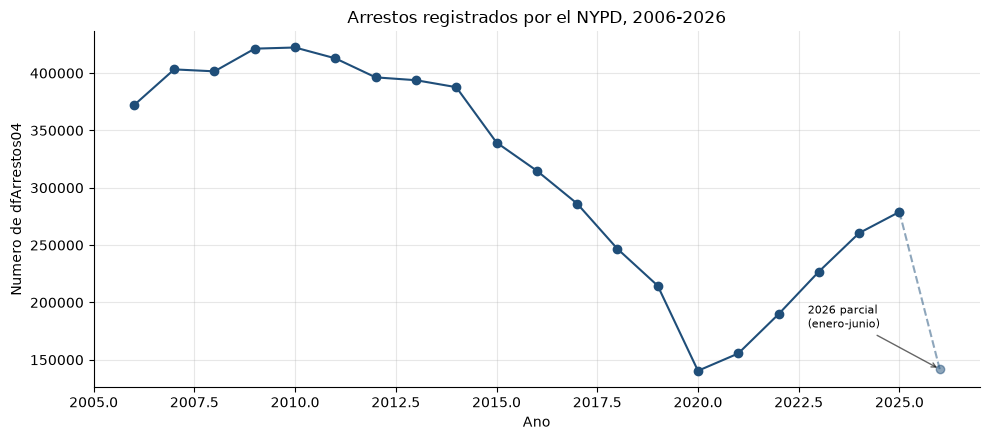

anio,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
Arrestos,371.934,403.231,401.529,421.316,422.322,412.859,396.280,393.809,387.727,339.470,...,286.225,246.773,214.617,140.413,155.507,189.774,226.872,260.503,278.953,141.870


In [27]:
serie = (dfArrestos04.groupBy('anio').count()
         .orderBy('anio').toPandas().set_index('anio')['count'])

fig, ax = plt.subplots()
ax.plot(serie.index[:-1], serie.values[:-1], marker='o', color='#1f4e79')
ax.plot(serie.index[-2:], serie.values[-2:], marker='o', color='#1f4e79',
        linestyle='--', alpha=0.5)
ax.set_title('Arrestos registrados por el NYPD, 2006-2026')
ax.set_xlabel('Ano'); ax.set_ylabel('Numero de dfArrestos04')
ax.ticklabel_format(style='plain', axis='y')
ax.annotate('2026 parcial\n(enero-junio)', xy=(serie.index[-1], serie.values[-1]),
            xytext=(-95, 30), textcoords='offset points', fontsize=8,
            arrowprops=dict(arrowstyle='->', alpha=0.6))
plt.tight_layout(); plt.show()

serie.apply(lambda v: format(v, ',').replace(',', '.')).to_frame('Arrestos').T


#### Se Observa
- La serie describe tres fases. Un periodo alto entre 2006 y 2012, con máximo en 2010 de 422.322 arrestos; un descenso sostenido que se acelera hasta el mínimo de 140.413 en 2020; y una recuperación parcial que alcanza 278.953 en 2025.
- El mínimo de 2020 coincide con la pandemia y representa apenas un tercio del máximo histórico.
- El valor de 2026 corresponde únicamente al primer semestre, por lo que se marca con línea discontinua para evitar que se lea como un desplome.

#### Interpretación para el negocio
- El indicador que motiva el encargo no está en deterioro: viene de una caída de largo plazo y de una recuperación parcial. El objetivo no es revertir una crisis sino focalizar mejor.


### Elemento 2. Arrestos por distrito: volumen absoluto frente a tasa poblacional

El volumen absoluto de arrestos favorece a los distritos más poblados y, por sí solo,
induce a error en la priorización territorial. Se normaliza el indicador por cada cien mil
habitantes, empleando como denominador la población estimada con los factores de expansión
del ACS 2023, de manera que numerador y denominador correspondan al mismo año.


In [28]:
# Poblacion por distrito en el ano de referencia, segun los pesos del ACS 2023
poblacion = (dfPums02.groupBy('distrito')
             .agg(F.sum('peso').alias('poblacion'))
             .toPandas().set_index('distrito')['poblacion'])

print('Poblacion estimada de la ciudad en %d: %s'
      % (ANO_REF, format(int(poblacion.sum()), ',').replace(',', '.')))
poblacion.apply(lambda v: format(int(v), ',').replace(',', '.')).to_frame('Habitantes')


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Poblacion estimada de la ciudad en 2023: 8.257.860


,Habitantes
distrito,
Queens,2.252.037
Brooklyn,2.560.271
Staten Island,490.802
Manhattan,1.597.842
Bronx,1.356.908


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


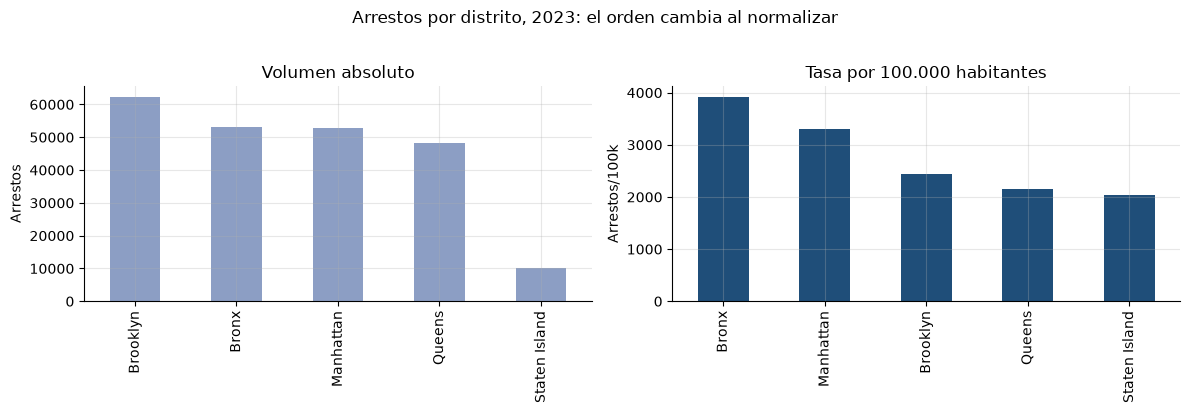

,Arrestos 2023,Poblacion,Por 100k hab
distrito,,,
Brooklyn,62395,2560271.0,2437.0
Bronx,53258,1356908.0,3925.0
Manhattan,52891,1597842.0,3310.0
Queens,48310,2252037.0,2145.0
Staten Island,10018,490802.0,2041.0


In [29]:
arr_ref = (dfArrestos04.filter(F.col('anio') == ANO_REF)
           .groupBy('distrito').count().toPandas()
           .dropna().set_index('distrito')['count'])

col_arr = 'Arrestos %d' % ANO_REF
comp = pd.DataFrame({col_arr: arr_ref, 'Poblacion': poblacion})
comp['Por 100k hab'] = (100000 * comp[col_arr] / comp['Poblacion']).round(0)
comp = comp.sort_values(col_arr, ascending=False)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
comp[col_arr].plot.bar(ax=a1, color='#8c9ec4')
a1.set_title('Volumen absoluto'); a1.set_xlabel(''); a1.set_ylabel('Arrestos')
comp['Por 100k hab'].sort_values(ascending=False).plot.bar(ax=a2, color='#1f4e79')
a2.set_title('Tasa por 100.000 habitantes'); a2.set_xlabel('')
a2.set_ylabel('Arrestos/100k')
plt.suptitle('Arrestos por distrito, %d: el orden cambia al normalizar' % ANO_REF, y=1.02)
plt.tight_layout(); plt.show()

comp


#### Se Observa
- Brooklyn encabeza el volumen absoluto con 62.395 arrestos, pero **desciende al tercer lugar** al considerar su población de 2.560.271 habitantes.
- El Bronx, segundo en términos absolutos, presenta la mayor incidencia real: 3.925 arrestos por cada cien mil habitantes, un **61% por encima** de Brooklyn.
- Staten Island es último en ambas lecturas.

#### Decisión y consecuencia para el plan de acción
- Toda priorización territorial debe realizarse sobre la tasa y no sobre el volumen. Una lectura basada en cifras absolutas llevaría a destinar recursos a Brooklyn cuando el territorio de mayor incidencia es el Bronx.
- El denominador se obtiene de los factores de expansión del propio ACS 2023, de modo que numerador y denominador corresponden al mismo año y no se introduce ninguna fuente externa.


### Elemento 3. Composición de los arrestos por gravedad y tipo de delito


In [30]:
GRAVEDAD = {'F': 'Delito grave (felony)', 'M': 'Delito menor (misdemeanor)',
            'V': 'Contravencion (violation)', 'I': 'Infraccion'}

grav = (dfArrestos04.groupBy('LAW_CAT_CD').count().toPandas()
        .assign(Categoria=lambda d: d['LAW_CAT_CD'].map(GRAVEDAD).fillna('Sin clasificar'))
        .groupby('Categoria')['count'].sum().sort_values(ascending=False))
grav_pct = (100 * grav / grav.sum()).round(2)
pd.DataFrame({'Arrestos': grav, '% del total': grav_pct})


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,Arrestos,% del total
Categoria,,
Delito menor (misdemeanor),4110313,64.15
Delito grave (felony),1934904,30.20
Contravencion (violation),303682,4.74
Sin clasificar,30444,0.48
Infraccion,27505,0.43


#### Se Observa
- Casi dos tercios de los arrestos, el 64,15%, corresponden a delitos menores (*misdemeanor*), frente al 30,20% de delitos graves (*felony*).
- Las categorías residuales, contravenciones e infracciones, suman menos del 6%.

#### Interpretación para el negocio
- La composición indica que el indicador no está dominado por criminalidad grave. Una política orientada exclusivamente a delitos graves actuaría sobre menos de un tercio del volumen total.


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


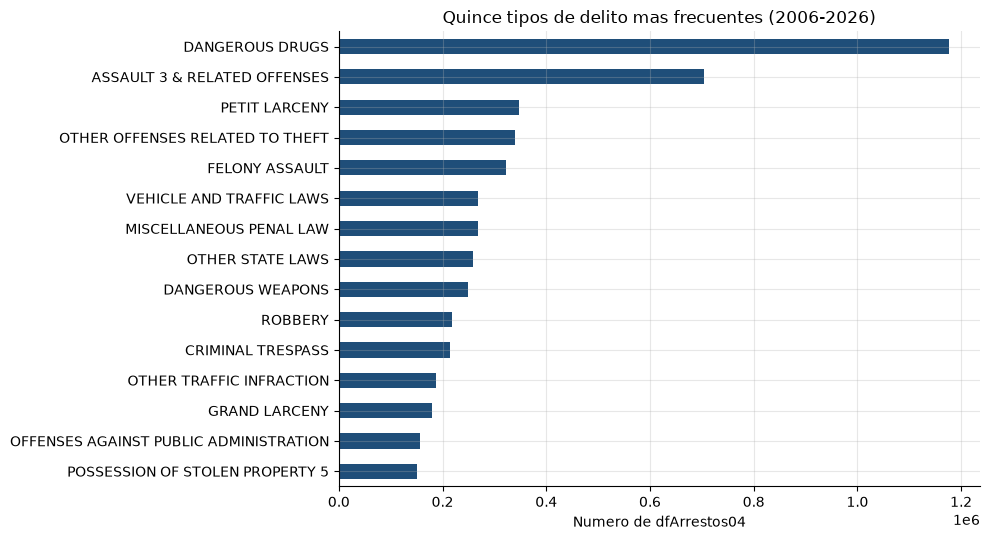

,Arrestos
OFNS_DESC,
DANGEROUS DRUGS,1177541
ASSAULT 3 & RELATED OFFENSES,705061
PETIT LARCENY,347258
OTHER OFFENSES RELATED TO THEFT,340186
FELONY ASSAULT,323220
VEHICLE AND TRAFFIC LAWS,267824
MISCELLANEOUS PENAL LAW,267818
OTHER STATE LAWS,258962
DANGEROUS WEAPONS,249016


In [31]:
top_delitos = (dfArrestos04.filter(F.col('OFNS_DESC').isNotNull())
               .groupBy('OFNS_DESC').count()
               .orderBy(F.desc('count')).limit(15).toPandas()
               .set_index('OFNS_DESC')['count'])

fig, ax = plt.subplots(figsize=(10, 5.5))
top_delitos.sort_values().plot.barh(ax=ax, color='#1f4e79')
ax.set_title('Quince tipos de delito mas frecuentes (2006-2026)')
ax.set_xlabel('Numero de dfArrestos04'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

top_delitos.to_frame('Arrestos')


#### Se Observa
- La categoría más frecuente es la relacionada con estupefacientes, con 1.177.541 arrestos, que por sí sola representa el **18,4%** de la serie completa y casi duplica a la segunda.
- Le siguen las agresiones y los hurtos menores.

#### Interpretación para el negocio
- Una fracción sustancial del indicador responde a una tipología delictiva específica y concentrada, susceptible de abordarse mediante políticas sanitarias y sociales distintas de las estrictamente policiales. Es uno de los hallazgos de mayor valor para el plan de acción.


### Elemento 4. Perfil demográfico de las personas arrestadas


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


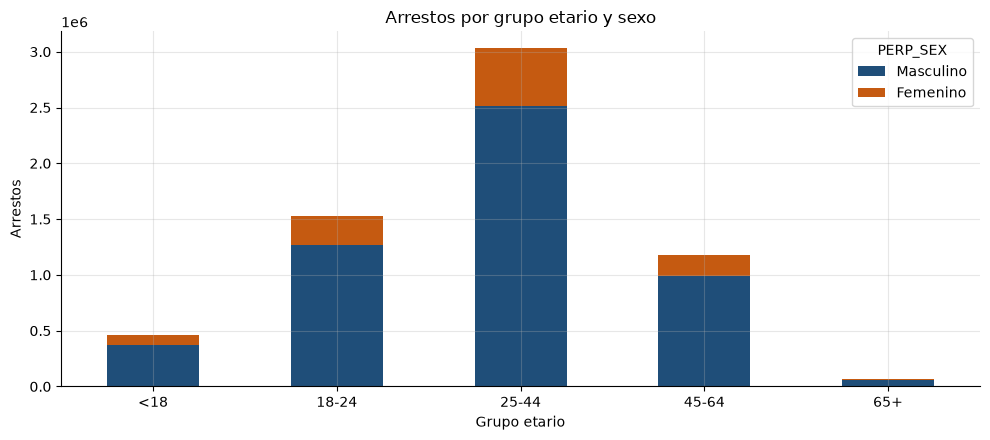

PERP_SEX,Femenino,Masculino,Total,% femenino
AGE_GROUP,,,,
<18,90515.0,367438.0,457953.0,19.77
18-24,259407.0,1270031.0,1529438.0,16.96
25-44,514080.0,2516916.0,3030996.0,16.96
45-64,187343.0,986923.0,1174266.0,15.95
65+,9271.0,53988.0,63259.0,14.66


In [32]:
demo = (dfArrestos04.filter(F.col('PERP_SEX').isin('M', 'F'))
        .groupBy('AGE_GROUP', 'PERP_SEX').count().toPandas()
        .pivot(index='AGE_GROUP', columns='PERP_SEX', values='count')
        .rename(columns={'F': 'Femenino', 'M': 'Masculino'}))
orden = ['<18', '18-24', '25-44', '45-64', '65+']
demo = demo.reindex([o for o in orden if o in demo.index])
demo['Total'] = demo.sum(axis=1)
demo['% femenino'] = (100 * demo['Femenino'] / demo['Total']).round(2)

fig, ax = plt.subplots()
demo[['Masculino', 'Femenino']].plot.bar(ax=ax, stacked=True,
                                         color=['#1f4e79', '#c55a11'])
ax.set_title('Arrestos por grupo etario y sexo')
ax.set_xlabel('Grupo etario'); ax.set_ylabel('Arrestos')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

demo


#### Se Observa
- El grupo de 25 a 44 años concentra el 48,45% de los arrestos con sexo declarado.
- La participación femenina desciende de forma monótona con la edad, desde el 19,77% entre los menores de edad hasta el 14,66% entre los mayores de 65 años.
- Los menores de 18 años acumulan 457.953 arrestos en el periodo.

#### Interpretación para el negocio
- El volumen de arrestos de menores de edad define la población sobre la cual una intervención preventiva tiene mayor recorrido, y motiva una de las preguntas de negocio planteadas para la entrega final.


### Elemento 5. Concentración territorial: precintos con mayor número de arrestos

El precinto policial constituye la unidad geográfica más fina disponible en el conjunto de
arrestos, y resulta más útil que el distrito para orientar la asignación de recursos.


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


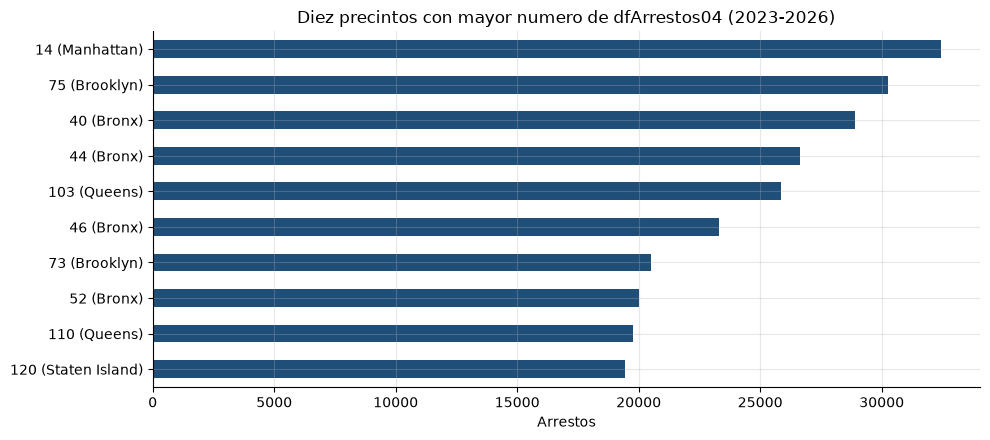

Los diez precintos concentran el 27.21% de los dfArrestos04 del periodo


,Arrestos
Precinto,
14 (Manhattan),32424
75 (Brooklyn),30274
40 (Bronx),28897
44 (Bronx),26648
103 (Queens),25842
46 (Bronx),23324
73 (Brooklyn),20498
52 (Bronx),20024
110 (Queens),19771


In [33]:
top_prec = (dfArrestos04.filter(F.col('anio') >= 2023)
            .groupBy('ARREST_PRECINCT', 'distrito').count()
            .orderBy(F.desc('count')).limit(10).toPandas())
top_prec['Precinto'] = (top_prec['ARREST_PRECINCT'].astype('Int64').astype(str)
                        + ' (' + top_prec['distrito'].fillna('n/d') + ')')
s = top_prec.set_index('Precinto')['count']

fig, ax = plt.subplots()
s.sort_values().plot.barh(ax=ax, color='#1f4e79')
ax.set_title('Diez precintos con mayor numero de dfArrestos04 (2023-2026)')
ax.set_xlabel('Arrestos'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

total_todos = dfArrestos04.filter(F.col('anio') >= 2023).count()
print('Los diez precintos concentran el %.2f%% de los dfArrestos04 del periodo'
      % (100 * s.sum() / total_todos))
s.to_frame('Arrestos')


#### Se Observa
- Los diez precintos señalados concentran el **27,21%** de los arrestos del periodo, aunque la ciudad cuenta con setenta y siete precintos.
- Cuatro de los diez pertenecen al Bronx, lo que refuerza el hallazgo del Elemento 2.
- El precinto 14, correspondiente a Midtown South en Manhattan, encabeza la lista con 32.424 arrestos.

#### Interpretación para el negocio
- El precinto es la unidad sobre la que efectivamente se asignan recursos policiales, de modo que esta concentración es más operativa que la distribución por distrito: intervenir en el 13% de los precintos alcanzaría a más de una cuarta parte de los arrestos.


### Elemento 6. Estacionalidad y evolución de los siniestros viales


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


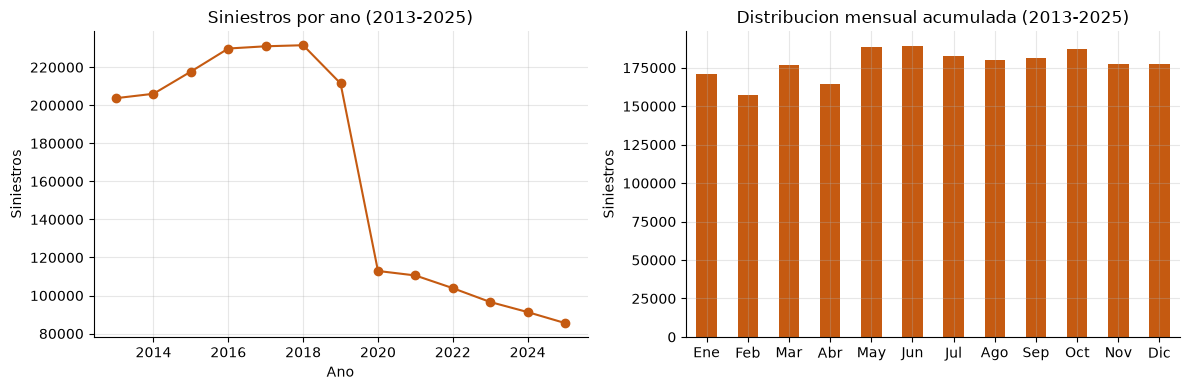

anio,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
Siniestros,100545,203742,206046,217708,229833,231007,231564,211486,112918,110558,103887,96607,91316,85546,36424


In [34]:
sin_anio = (dfSiniestros01.groupBy('anio').count().orderBy('anio').toPandas()
            .set_index('anio')['count'])
MESES = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
         'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
sin_mes = (dfSiniestros01.filter(F.col('anio').between(2013, 2025))
           .groupBy(F.month('crash_date').alias('mes')).count()
           .orderBy('mes').toPandas().set_index('mes')['count'])
sin_mes.index = MESES

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(sin_anio.index[1:-1], sin_anio.values[1:-1], marker='o', color='#c55a11')
a1.set_title('Siniestros por ano (2013-2025)'); a1.set_xlabel('Ano')
a1.set_ylabel('Siniestros')
sin_mes.plot.bar(ax=a2, color='#c55a11')
a2.set_title('Distribucion mensual acumulada (2013-2025)')
a2.set_xlabel(''); a2.set_ylabel('Siniestros')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

pd.DataFrame({'Siniestros': sin_anio}).T


#### Se Observa
- Los siniestros alcanzan su máximo en 2018 con 231.564 registros y descienden de forma sostenida hasta 85.546 en 2025, una reducción del **63%**.
- El comportamiento mensual es comparativamente estable, con una leve disminución en febrero atribuible a su menor número de días y no a un patrón de movilidad.

#### Interpretación para el negocio
- La trayectoria es coherente con la iniciativa Vision Zero, vigente desde 2014, y con el mínimo histórico de 205 fallecidos que la ciudad registró en 2025.


### Elemento 7. Distribución horaria de los siniestros

El atributo `crash_time` se almacena como texto en formato `H:MM`. Se extrae la hora para
identificar las franjas de mayor exposición al riesgo.


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


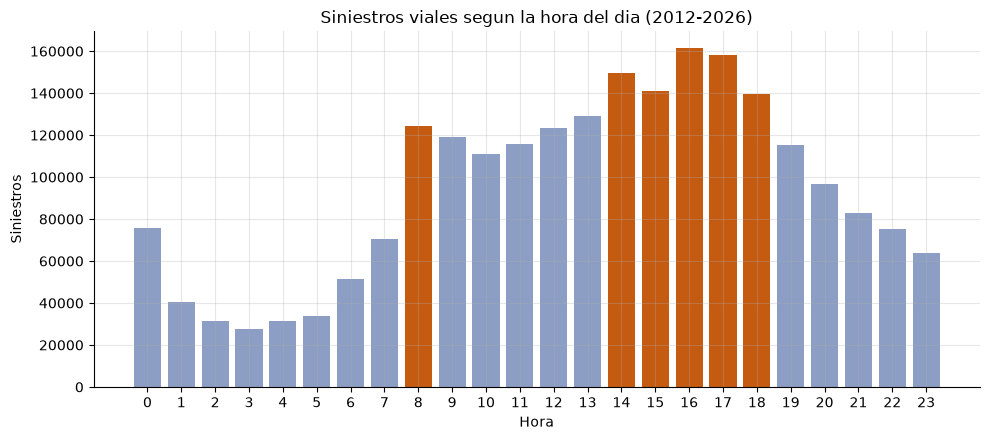

Franja de mayor incidencia: 16:00 horas, con 161.385 dfSiniestros01


hora,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Siniestros,75806,40498,31269,27571,31321,33878,51553,70581,124228,118950,...,149385,141172,161385,158232,139496,115262,96751,82841,75404,63665


In [35]:
por_hora = (dfSiniestros01
            .withColumn('hora', F.split('crash_time', ':').getItem(0).cast('int'))
            .filter(F.col('hora').between(0, 23))
            .groupBy('hora').count().orderBy('hora').toPandas()
            .set_index('hora')['count'])

fig, ax = plt.subplots()
colores = ['#c55a11' if h in (8, 14, 15, 16, 17, 18) else '#8c9ec4'
           for h in por_hora.index]
ax.bar(por_hora.index, por_hora.values, color=colores)
ax.set_title('Siniestros viales segun la hora del dia (2012-2026)')
ax.set_xlabel('Hora'); ax.set_ylabel('Siniestros'); ax.set_xticks(range(0, 24))
plt.tight_layout(); plt.show()

print('Franja de mayor incidencia: %d:00 horas, con %s dfSiniestros01'
      % (por_hora.idxmax(), format(int(por_hora.max()), ',').replace(',', '.')))
por_hora.to_frame('Siniestros').T


#### Se Observa
- La franja de mayor incidencia se sitúa a las 16:00 horas, con 161.385 siniestros, dentro de una banda crítica que se extiende de las 14:00 a las 18:00.
- Se observa un valor **anómalo en la hora 0:00**, con 75.806 registros, muy superior a los 40.498 de la hora siguiente y a los 63.665 de la anterior.

#### Decisión
- Ese pico aislado es incompatible con un patrón de movilidad real y sugiere que `00:00` opera como valor por defecto cuando la hora no se conoce.
- Se trata de un segundo marcador encubierto, análogo al literal `s` del SAT, y debe marcarse como hora desconocida en lugar de conservarse: su inclusión distorsionaría cualquier recomendación sobre franjas de fiscalización.


### Elemento 8. Gravedad de los siniestros por distrito

Se contrastan el volumen de siniestros, las víctimas y la letalidad, normalizando por la
población del mismo año de referencia. El análisis se restringe a los registros que cuentan
con distrito informado, circunstancia que afecta al 30,5% del conjunto y que se aborda en
el apartado de limpieza.


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


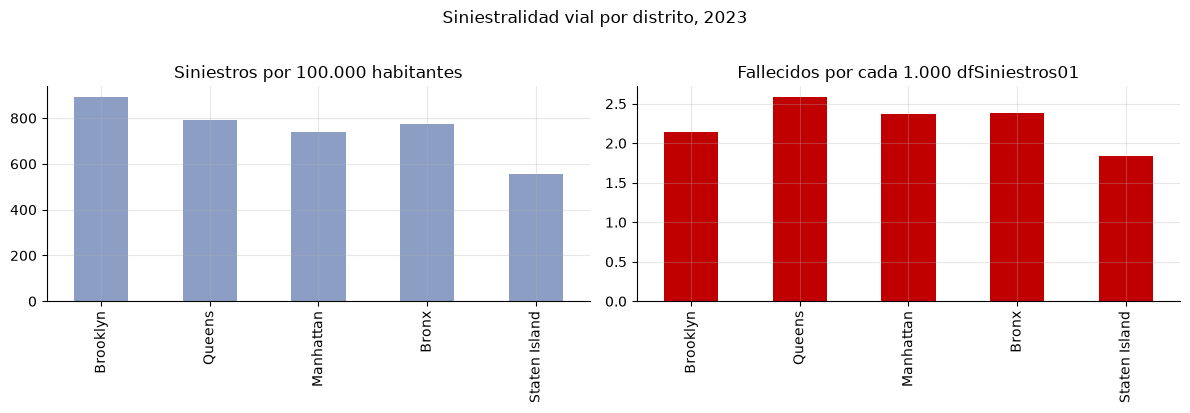

,Siniestros,Heridos,Fallecidos,Peatones fallecidos,Ciclistas fallecidos,Poblacion,Siniestros/100k,Letalidad (x1000 sin.)
distrito,,,,,,,,
Brooklyn,22890,12376,49,22,9,2560271.0,894.0,2.14
Queens,17786,9518,46,15,5,2252037.0,790.0,2.59
Manhattan,11823,5613,28,14,6,1597842.0,740.0,2.37
Bronx,10507,5811,25,7,3,1356908.0,774.0,2.38
Staten Island,2724,1366,5,2,1,490802.0,555.0,1.84


In [36]:
grav_sin = (dfSiniestros01.filter(F.col('borough').isNotNull() &
                              (F.col('anio') == ANO_REF))
            .groupBy('borough')
            .agg(F.count('*').alias('Siniestros'),
                 F.sum('n_persons_injured').alias('Heridos'),
                 F.sum('n_persons_killed').alias('Fallecidos'),
                 F.sum('n_pedestrians_killed').alias('Peatones fallecidos'),
                 F.sum('n_cyclist_killed').alias('Ciclistas fallecidos'))
            .toPandas())
grav_sin['distrito'] = grav_sin['borough'].str.title()
grav_sin = grav_sin.set_index('distrito').drop(columns='borough')
grav_sin['Poblacion'] = poblacion
grav_sin['Siniestros/100k'] = (100000 * grav_sin['Siniestros'] / grav_sin['Poblacion']).round(0)
grav_sin['Letalidad (x1000 sin.)'] = (1000 * grav_sin['Fallecidos'] / grav_sin['Siniestros']).round(2)
grav_sin = grav_sin.sort_values('Siniestros', ascending=False)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
grav_sin['Siniestros/100k'].plot.bar(ax=a1, color='#8c9ec4')
a1.set_title('Siniestros por 100.000 habitantes'); a1.set_xlabel('')
grav_sin['Letalidad (x1000 sin.)'].plot.bar(ax=a2, color='#c00000')
a2.set_title('Fallecidos por cada 1.000 dfSiniestros01'); a2.set_xlabel('')
plt.suptitle('Siniestralidad vial por distrito, %d' % ANO_REF, y=1.02)
plt.tight_layout(); plt.show()

grav_sin


#### Se Observa
- El ordenamiento de la siniestralidad **difiere del de los arrestos**: Brooklyn encabeza la incidencia por habitante con 894 siniestros por cien mil, mientras que el Bronx ocupa la tercera posición.
- Queens presenta la mayor letalidad de la ciudad, 2,59 fallecidos por cada mil siniestros, pese a no ser el de mayor incidencia.
- Staten Island combina la menor incidencia, 555 por cien mil, con la menor letalidad, 1,84.

#### Interpretación para el negocio
- Los dos indicadores del encargo **no identifican el mismo territorio prioritario**. Un plan de acción único para ambos sería inadecuado: la seguridad ciudadana apunta al Bronx y la seguridad vial a Brooklyn.
- La disociación entre incidencia y letalidad implica además que reducir el número de siniestros y reducir las muertes requieren medidas distintas.


### Elemento 9. Factores contribuyentes declarados en los siniestros


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


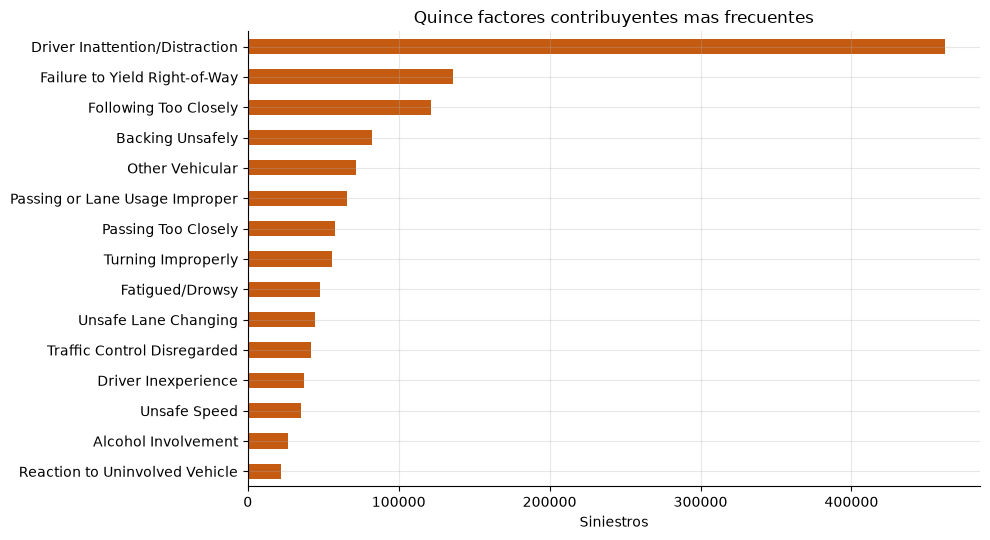

Registros con factor no especificado: 756.643 (33.3% del total)


,Siniestros
factor_1,
Driver Inattention/Distraction,462105
Failure to Yield Right-of-Way,136046
Following Too Closely,121711
Backing Unsafely,82577
Other Vehicular,71429
Passing or Lane Usage Improper,65544
Passing Too Closely,58028
Turning Improperly,55751
Fatigued/Drowsy,47599


In [37]:
factores = (dfSiniestros01.filter(F.col('factor_1').isNotNull() &
                              (F.col('factor_1') != 'Unspecified'))
            .groupBy('factor_1').count()
            .orderBy(F.desc('count')).limit(15).toPandas()
            .set_index('factor_1')['count'])

fig, ax = plt.subplots(figsize=(10, 5.5))
factores.sort_values().plot.barh(ax=ax, color='#c55a11')
ax.set_title('Quince factores contribuyentes mas frecuentes')
ax.set_xlabel('Siniestros'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

sin_espec = dfSiniestros01.filter(F.col('factor_1') == 'Unspecified').count()
print('Registros con factor no especificado: %s (%.1f%% del total)'
      % (format(sin_espec, ',').replace(',', '.'),
         100 * sin_espec / dfSiniestros01.count()))
factores.to_frame('Siniestros')


#### Se Observa
- La distracción del conductor domina de manera inequívoca con 462.105 siniestros, cifra que triplica con holgura la del segundo factor.
- Los cinco primeros factores remiten a **conductas de conducción** y no a condiciones de la infraestructura.
- No obstante, 756.643 siniestros, el 33,3% del conjunto, registran el factor como `Unspecified`.

#### Decisión
- La jerarquía describe únicamente los dos tercios de casos en que el factor fue consignado, y así debe presentarse: omitir esa advertencia exageraría la solidez del hallazgo.
- `Unspecified` se conserva como categoría propia en los conteos generales, porque es una respuesta válida del formulario y no una ausencia de dato.


### Elemento 10. Los datos ausentes como fenómeno temporal

El conjunto *Vehicles* presenta más de la mitad de los registros sin sexo del conductor ni
estado de la licencia. La hipótesis que se pone a prueba es que dicha ausencia no obedece a
un deterioro aleatorio de la calidad, sino a la modificación del formulario de captura
introducida en un momento determinado. De confirmarse, la estrategia de tratamiento no debe
ser la imputación, sino la restricción de la ventana temporal de análisis.


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


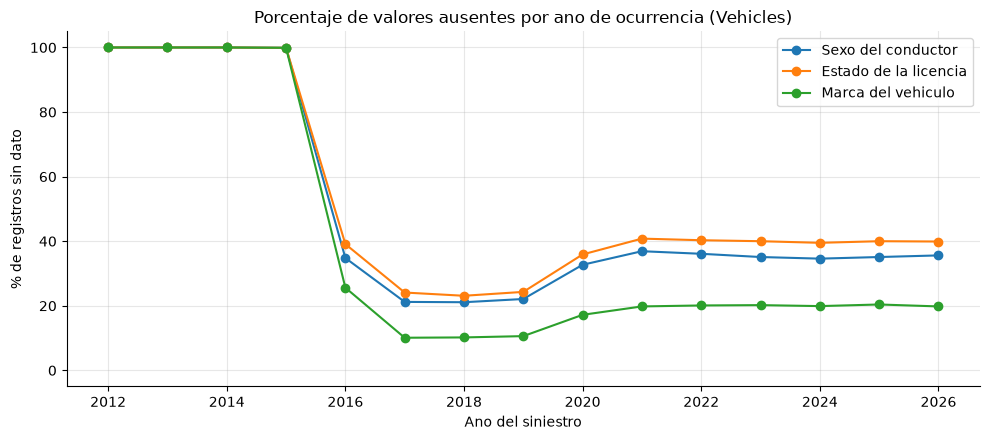

,registros,% sin_sexo,% sin_licencia,% sin_marca
anio,,,,
2012,198968,100.0,100.0,100.0
2013,404702,100.0,100.0,100.0
2014,409087,100.0,100.0,100.0
2015,434607,99.9,99.9,99.9
2016,457944,34.8,39.1,25.6
2017,464544,21.2,24.1,10.1
2018,465822,21.1,23.1,10.2
2019,426724,22.1,24.3,10.6
2020,231211,32.7,35.9,17.2


In [38]:
calidad_anual = (dfVehiculos02
                 .withColumn('anio', F.year('crash_date'))
                 .filter(F.col('anio').between(2012, 2026))
                 .groupBy('anio')
                 .agg(F.count('*').alias('registros'),
                      F.count(F.when(F.col('driver_sex').isNull(), 1)).alias('sin_sexo'),
                      F.count(F.when(F.col('driver_license_status').isNull(), 1)).alias('sin_licencia'),
                      F.count(F.when(F.col('vehicle_make').isNull(), 1)).alias('sin_marca'))
                 .orderBy('anio').toPandas().set_index('anio'))

for c in ['sin_sexo', 'sin_licencia', 'sin_marca']:
    calidad_anual['% ' + c] = (100 * calidad_anual[c] / calidad_anual['registros']).round(1)

fig, ax = plt.subplots()
for c, et in [('% sin_sexo', 'Sexo del conductor'),
              ('% sin_licencia', 'Estado de la licencia'),
              ('% sin_marca', 'Marca del vehiculo')]:
    ax.plot(calidad_anual.index, calidad_anual[c], marker='o', label=et)
ax.set_title('Porcentaje de valores ausentes por ano de ocurrencia (Vehicles)')
ax.set_xlabel('Ano del siniestro'); ax.set_ylabel('% de registros sin dato')
ax.set_ylim(-5, 105); ax.legend()
plt.tight_layout(); plt.show()

calidad_anual[['registros', '% sin_sexo', '% sin_licencia', '% sin_marca']]


#### Se Observa
- La ausencia de datos **no se degrada progresivamente**: cae de forma abrupta del 99,9% al 34,8% entre 2015 y 2016.
- Entre 2012 y 2015 los atributos del conductor y del vehículo están ausentes en prácticamente el 100% de los registros.
- Desde 2016 se estabilizan en una banda del 20% al 40%, con una leve subida a partir de 2020.

#### Decisión
- Queda demostrado que la ausencia es **estructural y no aleatoria**: esos atributos sencillamente no se capturaban antes de 2016, cuando se modificó el formulario.
- Por consiguiente **no deben imputarse**. Hacerlo equivaldría a fabricar información para más de 1,4 millones de registros en los que nunca se recogió dato alguno.
- El tratamiento correcto es restringir la ventana temporal a 2016 en adelante para toda variable relativa al conductor, aceptando la pérdida de cobertura a cambio de validez.

Este elemento ilustra por qué un reporte de calidad no puede limitarse a contar ausencias: la misma cifra del 51,62% admite dos tratamientos opuestos según se interprete como deterioro aleatorio o como cambio en el instrumento de captura.


### Elemento 11. Pobreza por distrito

La estimación de 2023 se calcula sobre los microdatos del ACS ponderando por el factor de
expansión `PWGTP`. Se considera en situación de pobreza a quien presenta una razón
ingreso-umbral inferior a 100; el denominador es el universo de pobreza, que excluye a la
población institucionalizada y a los menores de quince años no emparentados, conforme al
criterio del propio Censo.

Se incorpora como contraste la medida NYCgov de 2018, que figura en el enunciado. Ambas no
son directamente comparables: la medida NYCgov ajusta por costo de vida, impuestos y
transferencias, mientras que la del ACS emplea el umbral federal, que subestima la pobreza
en una ciudad de costos elevados. La comparación se presenta para apreciar la persistencia
del ordenamiento territorial, no para medir su variación.


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


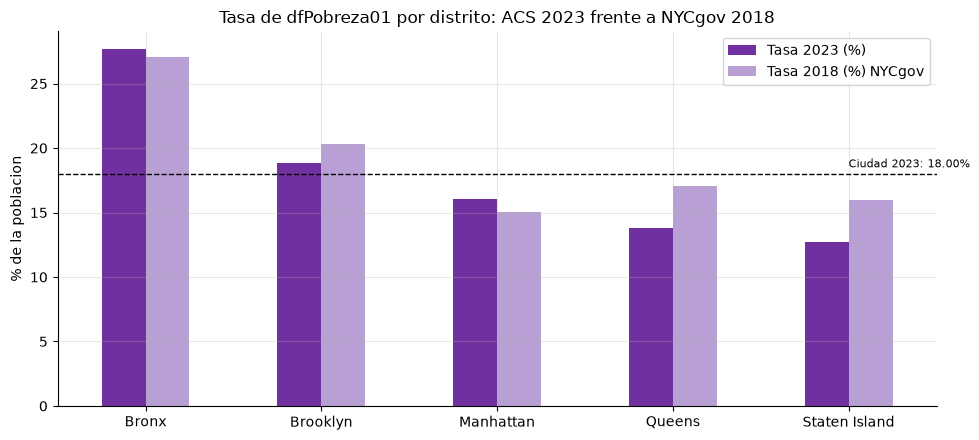

Tasa de dfPobreza01 de la ciudad en 2023: 18.00%
(cifra publicada para 2023 con la medida federal: 18,2%)


,Universo 2023,En dfPobreza01 2023,Tasa 2023 (%),Tasa 2018 (%) NYCgov
distrito,,,,
Bronx,1322073,365818,27.67,27.10
Brooklyn,2532309,476995,18.84,20.31
Manhattan,1541691,247200,16.03,15.06
Queens,2223873,307577,13.83,17.02
Staten Island,485385,61634,12.70,16.00


In [39]:
# --- Pobreza 2023, microdatos del ACS ---
pob_2023 = (dfPums02.groupBy('distrito')
            .agg(F.sum(F.when(F.col('ratio_pobreza').isNotNull(),
                              F.col('peso'))).alias('universo'),
                 F.sum(F.when(F.col('ratio_pobreza') < 100,
                              F.col('peso'))).alias('en_pobreza'))
            .toPandas().set_index('distrito'))
pob_2023['Tasa 2023 (%)'] = (100 * pob_2023['en_pobreza'] / pob_2023['universo']).round(2)

# --- Pobreza 2018, medida NYCgov del enunciado ---
pob_2018 = (dfPobreza01.groupBy('boro')
            .agg(F.sum('pwgtp').alias('poblacion'),
                 F.sum(F.when(F.col('nycgov_pov_stat') == 1,
                              F.col('pwgtp')).otherwise(0)).alias('en_pobreza'))
            .toPandas())
pob_2018['distrito'] = pob_2018['boro'].map(BORO_POBREZA)
pob_2018 = pob_2018.set_index('distrito')
pob_2018['Tasa 2018 (%)'] = (100 * pob_2018['en_pobreza'] / pob_2018['poblacion']).round(2)

pob_dist = pd.DataFrame({
    'Universo 2023': pob_2023['universo'].astype('int64'),
    'En dfPobreza01 2023': pob_2023['en_pobreza'].astype('int64'),
    'Tasa 2023 (%)': pob_2023['Tasa 2023 (%)'],
    'Tasa 2018 (%) NYCgov': pob_2018['Tasa 2018 (%)'],
}).sort_values('Tasa 2023 (%)', ascending=False)

fig, ax = plt.subplots()
pob_dist[['Tasa 2023 (%)', 'Tasa 2018 (%) NYCgov']].plot.bar(
    ax=ax, color=['#7030a0', '#b9a0d4'])
tasa_ciudad = 100 * pob_2023['en_pobreza'].sum() / pob_2023['universo'].sum()
ax.axhline(tasa_ciudad, color='black', linestyle='--', linewidth=1)
ax.text(4.0, tasa_ciudad + 0.5, 'Ciudad 2023: %.2f%%' % tasa_ciudad, fontsize=8)
ax.set_title('Tasa de dfPobreza01 por distrito: ACS 2023 frente a NYCgov 2018')
ax.set_xlabel(''); ax.set_ylabel('% de la poblacion')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

print('Tasa de dfPobreza01 de la ciudad en 2023: %.2f%%' % tasa_ciudad)
print('(cifra publicada para 2023 con la medida federal: 18,2%)')
pob_dist


#### Se Observa
- La tasa obtenida para el conjunto de la ciudad en 2023, **18,00%**, coincide con la cifra de 18,2% publicada para ese año, lo que valida la identificación de los códigos geográficos y la aplicación de los factores de expansión.
- El Bronx mantiene la primera posición en ambas mediciones, con 27,67% en 2023, casi quince puntos por encima de Staten Island.
- Queens y Staten Island muestran diferencias apreciables entre 2018 y 2023.

#### Decisión
- Las dos columnas **no son directamente comparables**. La medida NYCgov ajusta por costo de vida, impuestos y transferencias; la del ACS emplea el umbral federal, que subestima la pobreza en una ciudad de costos elevados.
- La comparación se presenta para apreciar la persistencia del ordenamiento territorial, no para medir su variación. Interpretar la diferencia de Queens como una mejora real sería un error de lectura.
- La ponderación por `PWGTP` es indispensable: la muestra no es autoponderada y omitirla produciría cifras sesgadas.


### Elemento 12. Desempeño educativo por distrito

El indicador alineado con el año de referencia es la tasa de graduación a cuatro años de la
clase de 2023, que corresponde a la cohorte que ingresó en 2019.


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


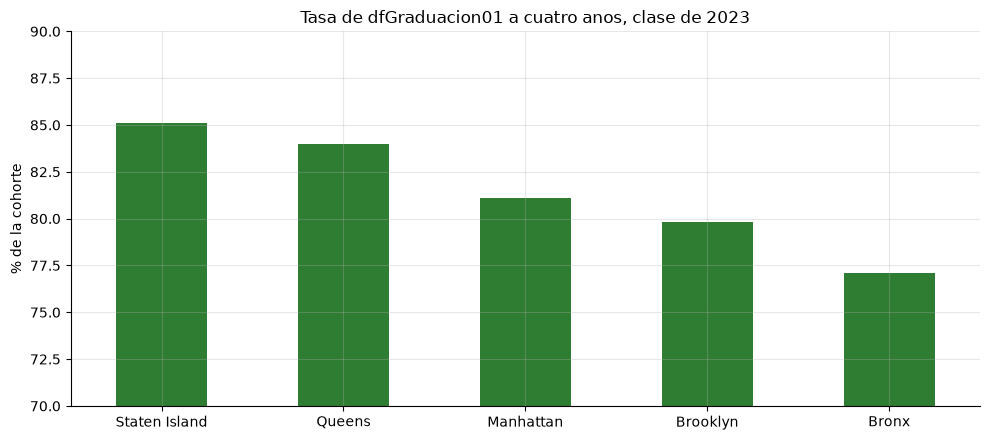

,Cohorte,Graduados,Graduacion 2023 (%)
distrito,,,
Staten Island,4583,3900,85.1
Queens,18712,15727,84.0
Manhattan,14660,11888,81.1
Brooklyn,19682,15698,79.8
Bronx,12256,9455,77.1


In [40]:
grad_ref = (dfGraduacion01.filter((F.col('nivel') == 'Borough') &
                              (F.col('categoria') == 'All Students') &
                              (F.col('cohorte_anio') == 2019) &
                              (F.col('cohorte_tipo') == '4 year June'))
            .select('distrito', 'total_cohorte', 'graduados', 'pct_graduados')
            .toPandas().set_index('distrito'))
grad_ref = grad_ref.rename(columns={'total_cohorte': 'Cohorte',
                                    'graduados': 'Graduados',
                                    'pct_graduados': 'Graduacion 2023 (%)'})
grad_ref = grad_ref.sort_values('Graduacion 2023 (%)', ascending=False)

fig, ax = plt.subplots()
grad_ref['Graduacion 2023 (%)'].plot.bar(ax=ax, color='#2e7d32')
ax.set_title('Tasa de dfGraduacion01 a cuatro anos, clase de 2023')
ax.set_xlabel(''); ax.set_ylabel('% de la cohorte'); ax.set_ylim(70, 90)
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

grad_ref


#### Se Observa
- La cohorte 2019 corresponde a la clase de 2023, de modo que este indicador queda alineado con el año de referencia del corte transversal.
- El Bronx presenta la menor tasa, 77,1%, y Staten Island la mayor, 85,1%: una diferencia de ocho puntos porcentuales.
- El ordenamiento es el **inverso exacto** del de la pobreza.

#### Decisión
- Se emplea el horizonte de cuatro años en junio, y no el de agosto, por ser la medición estándar de graduación oportuna.
- Se filtra el nivel `Borough` y la categoría de todos los estudiantes, que es la combinación que produce una fila por distrito.


#### Persistencia del ordenamiento educativo

Cabe preguntarse si recurrir a un único año introduce arbitrariedad. Se contrastan para ello
tres mediciones distintas separadas por once años: el puntaje SAT de 2012 que figura en el
enunciado, el puntaje medio de los exámenes Regents de 2019 y la tasa de graduación de la
clase de 2023. Si el ordenamiento entre distritos se mantiene, la elección del año resulta
indiferente para la priorización territorial.


In [41]:
BORO_DBN = {'X': 'Bronx', 'K': 'Brooklyn', 'M': 'Manhattan',
            'Q': 'Queens', 'R': 'Staten Island'}
expr_dbn = F.create_map([F.lit(x) for kv in BORO_DBN.items() for x in kv])

# SAT 2012, excluidas las instituciones con puntaje suprimido
sat_dist = (dfSat01.filter(F.col('sat_matematicas').rlike('^[0-9]+$'))
            .withColumn('distrito', expr_dbn[F.substring('dbn', 3, 1)])
            .withColumn('total', F.col('sat_lectura').cast('int') +
                                 F.col('sat_matematicas').cast('int') +
                                 F.col('sat_escritura').cast('int'))
            .groupBy('distrito')
            .agg(F.round(F.avg('total'), 1).alias('SAT 2012'))
            .toPandas().dropna(subset=['distrito']).set_index('distrito'))

# Regents 2019: promedio ponderado por numero de evaluados
reg_dist = (dfRegents01.filter((F.col('anio_escolar') == '2019') &
                           F.col('puntaje_medio').isNotNull() &
                           (F.col('evaluados') > 0))
            .withColumn('distrito', expr_dbn[F.substring('dbn', 3, 1)])
            .filter(F.col('distrito').isNotNull())
            .groupBy('distrito')
            .agg(F.round(F.sum(F.col('puntaje_medio') * F.col('evaluados')) /
                         F.sum('evaluados'), 1).alias('Regents 2019'),
                 F.sum('evaluados').alias('Evaluados'))
            .toPandas().set_index('distrito'))

edu = pd.DataFrame({'SAT 2012': sat_dist['SAT 2012'],
                    'Regents 2019': reg_dist['Regents 2019'],
                    'Graduacion 2023 (%)': grad_ref['Graduacion 2023 (%)']})
edu['Puesto SAT'] = edu['SAT 2012'].rank(ascending=True).astype(int)
edu['Puesto Regents'] = edu['Regents 2019'].rank(ascending=True).astype(int)
edu['Puesto dfGraduacion01'] = edu['Graduacion 2023 (%)'].rank(ascending=True).astype(int)
edu = edu.sort_values('Puesto dfGraduacion01')

print('Puesto 1 = desempeno mas bajo en cada medicion')
coinciden = (edu['Puesto SAT'].equals(edu['Puesto dfGraduacion01']) and
             edu['Puesto Regents'].equals(edu['Puesto dfGraduacion01']))
print('Ordenamiento identico en las tres mediciones:', coinciden)
edu


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Puesto 1 = desempeno mas bajo en cada medicion
Ordenamiento identico en las tres mediciones: False


,SAT 2012,Regents 2019,Graduacion 2023 (%),Puesto SAT,Puesto Regents,Puesto dfGraduacion01
distrito,,,,,,
Bronx,1144.6,66.8,77.1,1,1,1
Brooklyn,1167.4,70.3,79.8,2,2,2
Manhattan,1260.2,72.7,81.1,3,5,3
Queens,1275.4,72.1,84.0,4,4,4
Staten Island,1359.2,71.9,85.1,5,3,5


#### Se Observa
- El puntaje SAT de 2012 y la tasa de graduación de 2023 producen un **ordenamiento idéntico**, pese a mediar once años y tratarse de mediciones de naturaleza distinta.
- El examen Regents discrepa en Manhattan y Staten Island, lo que resulta atribuible a que mide la aprobación de exámenes concretos y depende de qué alumnos se presentan a cuáles.
- Las dos primeras posiciones desfavorables, Bronx y Brooklyn, son idénticas en las tres mediciones.

#### Interpretación para el negocio
- La identificación del territorio educativamente más rezagado **no depende del año ni del instrumento** empleado, mientras que el ordenamiento entre los distritos de mejor desempeño sí es sensible a ambos factores.
- Esto justifica que el conjunto SAT de 2012, aunque desfasado, conserve valor como caracterización estructural del territorio.


### Elemento 13. Convergencia territorial de los indicadores

Se consolidan en una sola tabla los indicadores construidos, **todos correspondientes a
2023**, lo que permite apreciar si los distritos con mayor incidencia de arrestos y
siniestros coinciden con aquellos de mayor pobreza y menor desempeño educativo. Se trata de
una descripción conjunta y en ningún caso de una relación causal; su contrastación formal
corresponde a la entrega final.


In [42]:
panel = pd.DataFrame({
    'Arrestos/100k': comp['Por 100k hab'],
    'Siniestros/100k': grav_sin['Siniestros/100k'],
    'Letalidad (x1000)': grav_sin['Letalidad (x1000 sin.)'],
    'Pobreza (%)': pob_dist['Tasa 2023 (%)'],
    'Graduacion (%)': grad_ref['Graduacion 2023 (%)'],
    'Poblacion': poblacion.astype('int64'),
})
panel = panel.sort_values('Arrestos/100k', ascending=False)
print('Todos los indicadores corresponden al ano %d' % ANO_REF)
panel


Todos los indicadores corresponden al ano 2023


,Arrestos/100k,Siniestros/100k,Letalidad (x1000),Pobreza (%),Graduacion (%),Poblacion
distrito,,,,,,
Bronx,3925.0,774.0,2.38,27.67,77.1,1356908
Manhattan,3310.0,740.0,2.37,16.03,81.1,1597842
Brooklyn,2437.0,894.0,2.14,18.84,79.8,2560271
Queens,2145.0,790.0,2.59,13.83,84.0,2252037
Staten Island,2041.0,555.0,1.84,12.70,85.1,490802


In [43]:
rank = pd.DataFrame({
    'Arrestos': panel['Arrestos/100k'].rank(ascending=False).astype(int),
    'Siniestros': panel['Siniestros/100k'].rank(ascending=False).astype(int),
    'Pobreza': panel['Pobreza (%)'].rank(ascending=False).astype(int),
    'Graduacion (menor tasa)': panel['Graduacion (%)'].rank(ascending=True).astype(int),
})
print('Posicion 1 = situacion mas desfavorable en cada indicador, ano %d' % ANO_REF)
rank


Posicion 1 = situacion mas desfavorable en cada indicador, ano 2023


,Arrestos,Siniestros,Pobreza,Graduacion (menor tasa)
distrito,,,,
Bronx,1,3,1,1
Manhattan,2,4,3,3
Brooklyn,3,1,2,2
Queens,4,2,4,4
Staten Island,5,5,5,5


#### Se Observa
- El Bronx ocupa la primera posición desfavorable en arrestos, pobreza y rezago educativo, y la tercera en siniestralidad.
- Staten Island ocupa la quinta posición en los cuatro indicadores.
- La coincidencia entre seguridad ciudadana, pobreza y educación es notable; la siniestralidad vial sigue en cambio un patrón propio, encabezado por Brooklyn.

#### Advertencia sobre Manhattan
- Ocupa la segunda posición en arrestos por habitante pese a registrar una pobreza inferior a la media de la ciudad, lo que rompe el patrón.
- La explicación más plausible es metodológica: los arrestos se contabilizan en el lugar de ocurrencia y no en el de residencia, y Manhattan recibe a diario una población flotante de trabajadores y visitantes que supera ampliamente a sus 1,60 millones de residentes. El denominador subestima la población realmente expuesta.

#### Límite de la interpretación
- Lo anterior es una descripción de **coincidencia territorial** y en ningún caso una relación de causalidad. Su contrastación formal corresponde a la entrega final.


### Elemento 14. Estabilidad del ordenamiento territorial

El corte transversal se construyó sobre 2023, pero las recomendaciones del plan de acción
se aplicarán en el presente. Procede entonces verificar si el ordenamiento de los distritos
se mantiene a lo largo del tiempo o si varía de un año a otro.

Si el ordenamiento es estable, un diagnóstico construido sobre cualquier año reciente
resulta válido para priorizar hoy, y la elección del año de referencia deja de ser una
fuente de incertidumbre. Si no lo es, la conclusión sería que la priorización debe
recalcularse de manera periódica, lo que constituye en sí mismo un hallazgo relevante para
el equipo de gobierno.

Se emplea como denominador la población de 2023 en todos los años, de modo que la
comparación aísle la variación del numerador.


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


/opt/cluster/spark/python/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


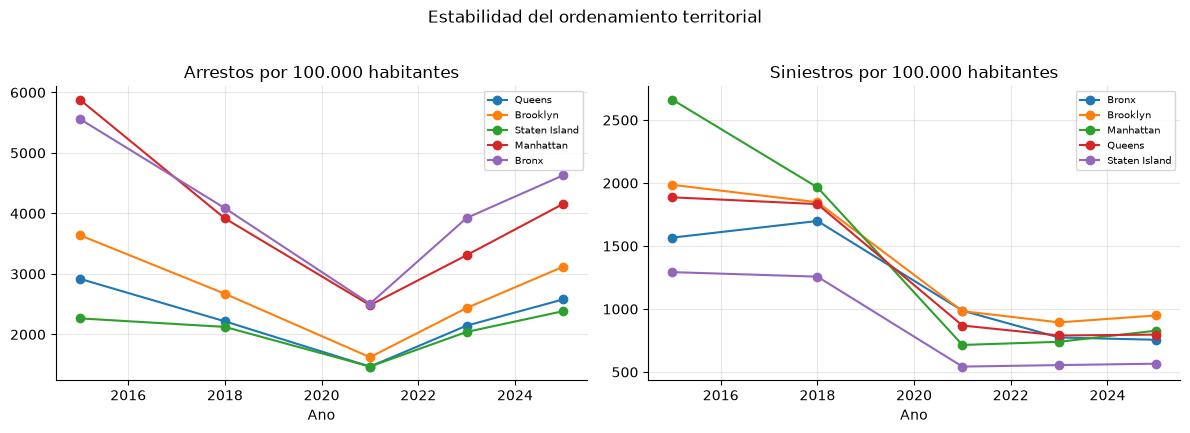

ARRESTOS por 100k
                 2015    2018    2021    2023    2025
distrito                                             
Queens         2919.0  2216.0  1468.0  2145.0  2579.0
Brooklyn       3640.0  2672.0  1623.0  2437.0  3120.0
Staten Island  2265.0  2124.0  1469.0  2041.0  2385.0
Manhattan      5880.0  3917.0  2483.0  3310.0  4159.0
Bronx          5561.0  4086.0  2507.0  3925.0  4631.0

SINIESTROS por 100k
                 2015    2018   2021   2023   2025
distrito                                          
Bronx          1567.0  1699.0  987.0  774.0  756.0
Brooklyn       1986.0  1848.0  983.0  894.0  949.0
Manhattan      2662.0  1966.0  715.0  740.0  828.0
Queens         1887.0  1833.0  869.0  790.0  797.0
Staten Island  1293.0  1257.0  543.0  555.0  566.0


In [44]:
ANIOS = [2015, 2018, 2021, 2023, 2025]

filas_arr, filas_sin = {}, {}
for a in ANIOS:
    s = (dfArrestos04.filter(F.col('anio') == a).groupBy('distrito').count()
         .toPandas().dropna().set_index('distrito')['count'])
    filas_arr[a] = (100000 * s / poblacion).round(0)
    t = (dfSiniestros01.filter(F.col('borough').isNotNull() & (F.col('anio') == a))
         .groupBy('borough').count().toPandas())
    t['distrito'] = t['borough'].str.title()
    t = t.set_index('distrito')['count']
    filas_sin[a] = (100000 * t / poblacion).round(0)

tasa_arr = pd.DataFrame(filas_arr)
tasa_sin = pd.DataFrame(filas_sin)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2))
for d in tasa_arr.index:
    a1.plot(tasa_arr.columns, tasa_arr.loc[d], marker='o', label=d)
a1.set_title('Arrestos por 100.000 habitantes'); a1.set_xlabel('Ano')
a1.legend(fontsize=7)
for d in tasa_sin.index:
    a2.plot(tasa_sin.columns, tasa_sin.loc[d], marker='o', label=d)
a2.set_title('Siniestros por 100.000 habitantes'); a2.set_xlabel('Ano')
a2.legend(fontsize=7)
plt.suptitle('Estabilidad del ordenamiento territorial', y=1.02)
plt.tight_layout(); plt.show()

print('ARRESTOS por 100k'); print(tasa_arr)
print(); print('SINIESTROS por 100k'); print(tasa_sin)


#### Se Observa
- Las tasas de arrestos descienden de forma generalizada hasta 2021 y se recuperan parcialmente después, conservando las distancias relativas entre distritos.
- Las tasas de siniestros caen con mucha mayor intensidad: Manhattan pasa de 2.662 a 740 por cien mil habitantes entre 2015 y 2023, una reducción del 72%.
- Staten Island mantiene la posición más baja en ambos indicadores durante todo el periodo.


In [45]:
# Puesto de cada distrito en cada ano (1 = mayor incidencia)
puestos_arr = tasa_arr.rank(ascending=False).astype(int)
puestos_sin = tasa_sin.rank(ascending=False).astype(int)

print('Puesto en ARRESTOS por 100k (1 = peor)')
print(puestos_arr)
print()
print('Puesto en SINIESTROS por 100k (1 = peor)')
print(puestos_sin)
print()
est_arr = (puestos_arr.nunique(axis=1) == 1).all()
est_sin = (puestos_sin.nunique(axis=1) == 1).all()
print('Ordenamiento de dfArrestos04 invariante en todos los anos  :', est_arr)
print('Ordenamiento de dfSiniestros01 invariante en todos los anos:', est_sin)
cambios_arr = puestos_arr.nunique(axis=1) - 1
print()
print('Numero de posiciones distintas ocupadas por cada distrito:')
print(pd.DataFrame({'Arrestos': puestos_arr.nunique(axis=1),
                    'Siniestros': puestos_sin.nunique(axis=1)}))


Puesto en ARRESTOS por 100k (1 = peor)
               2015  2018  2021  2023  2025
distrito                                   
Queens            4     4     5     4     4
Brooklyn          3     3     3     3     3
Staten Island     5     5     4     5     5
Manhattan         1     2     2     2     2
Bronx             2     1     1     1     1

Puesto en SINIESTROS por 100k (1 = peor)
               2015  2018  2021  2023  2025
distrito                                   
Bronx             4     4     1     3     4
Brooklyn          2     2     2     1     1
Manhattan         1     1     4     4     2
Queens            3     3     3     2     3
Staten Island     5     5     5     5     5

Ordenamiento de dfArrestos04 invariante en todos los anos  : False
Ordenamiento de dfSiniestros01 invariante en todos los anos: False

Numero de posiciones distintas ocupadas por cada distrito:
               Arrestos  Siniestros
distrito                           
Bronx                 2           3


#### Se Observa
- **Arrestos: ordenamiento estable.** El Bronx ocupa la primera posición en 2018, 2021, 2023 y 2025, y cada distrito ocupa como máximo dos posiciones distintas en diez años. La única alternancia relevante es el intercambio entre el Bronx y Manhattan en 2015.
- **Siniestros: ordenamiento inestable.** Manhattan desciende de la primera a la cuarta posición y el Bronx oscila entre la primera y la cuarta. Únicamente Staten Island mantiene una posición invariable.

#### Conclusión operativa para el equipo de gobierno
- La priorización territorial en materia de **seguridad ciudadana puede apoyarse en un diagnóstico estable**: el territorio de mayor incidencia es el mismo año tras año, de modo que una intervención planificada sobre el Bronx conserva su pertinencia.
- La priorización en materia de **seguridad vial debe recalcularse de manera periódica**, porque el ordenamiento se reconfigura en pocos años. Una política fijada sobre el diagnóstico de 2015 habría destinado los recursos a Manhattan, que hoy es el cuarto distrito.
- El caso de Manhattan constituye además la mejora más pronunciada de la ciudad y merece estudio específico como posible referencia de política pública transferible a otros distritos.

Este elemento responde a la objeción natural sobre el uso de un único año de referencia: la validez de hacerlo **depende del indicador**, y ahora está determinada con datos en lugar de supuesta.


---

*El cuaderno continúa en la entrega final con el planteamiento y la resolución de las
preguntas de negocio, así como con el proceso completo de limpieza y transformación.*
